# 2026 年中国研究生数学建模竞赛 D 题 · 问题一

## 单点往返运输能力与货箱组批方案

---

## 1 问题

| 项目 | 内容 |
| --- | --- |
| **研究对象** | 临时调度中心 O01 与 15 个服务区 S001–S015 之间的**单点直接往返架次** O01 → Sᵢ → O01 |
| **任务 1** | 计算三种机型（A/B/C）在各服务区执行单点往返时的**最大安全载荷** |
| **任务 2** | 在货箱不可拆、每箱只装一次、满足**载质量 / 装载体积 / 返航安全能量余量**的条件下，给出各服务区的货箱组批方案 |
| **任务 3** | 完成全部 80 箱交付前提下，综合**往返架次数、总运输能耗、累计作业时间**三指标优化组批，并说明指标之间的**权衡 / 优先关系** |
| **任务 4** | 讨论**返航安全余量 $\rho$** 变化对各机型最大安全载荷与组批结果的影响（敏感性分析） |
| **输入数据** | 节点坐标与海拔、30 m DEM、机型参数（质量、航程、能量、速度、效率、作业时间）、逐箱货箱清单 |
| **硬约束** | 不跨服务区组批；货箱不可拆分；每箱只安排一次；$\sum质量 \leq 机型最大载货质量且 \leq 能量允许载荷$；$\sum体积 \leq 可用装载体积$；架次总能耗 $\leq (1-\rho)E^{use}$ |
| **本问不考虑** | 实体无人机数量、共享电池周转、配送时限（时限在问题二才成为约束，本问仅用于确定首批货箱的排序偏好） |
| **论文必须呈现** | 最大安全载荷表（15×3）；逐箱组批方案表；三指标结果与权衡分析；$\rho$ 敏感性曲线与结论 |

## 2 技术路线

```text
地理数据（节点/DEM） ──▶ 航段几何模型 ──▶ 三阶段时间模型 ──┐
                           │（距离、像元遍历、巡航海拔）     │
                           ▼                            ▼
                能耗模型（等效航程 + 爬升做功） ──▶ 最大安全载荷（单调性 + 二分）
                                                       │
                                                       ▼
                货箱组批：装载模式枚举 ──▶ 多目标动态规划（Pareto 剪枝） ──▶ 策略选择与权衡
                                              │
                                              ▼
           返航安全余量 ρ 的敏感性扫描（载荷 / 架次 / 能耗 / 时间 / 可行域）
```

三条路线上的每个环节都对应论文中的一小节

## 3 题目统一规则的数学化（附录 2 的逐条解读）

**（1）架次结构。** 一个架次 $p=(g,i)$ 由机型 $g\in\{A,B,C\}$ 执行，路径为 $O_{01}\rightarrow S_i\rightarrow O_{01}$。去程携带载荷 $q$（该批货箱总质量），回程空载 $q=0$。

**（2）巡航海拔与作业高度。** 航段取两节点间水平直线；**计划巡航海拔** $H_i^c=\max[\mathrm{DEM}(\text{航段所经像元})]+50\ \mathrm m$。$O_{01}$ 作业高度取其地面海拔 $z_O$；服务区作业高度取 $z_{S_i}+30\ \mathrm m$。于是：

$$
h_{\mathrm{out}}^{+}=H_i^c-z_O,\qquad h_{\mathrm{out}}^{-}=H_i^c-(z_{S_i}+30),\qquad h_{\mathrm{ret}}^{+}=H_i^c-(z_{S_i}+30),\qquad h_{\mathrm{ret}}^{-}=H_i^c-z_O.
$$

**（3）三阶段飞行时间。** 每个航段按“爬升—巡航—下降”串行计算：

$$
t_{gij}=\frac{h_{ij}^{+}}{v_g^{\uparrow}}+\frac{d_{ij}}{v_g^{c}}+\frac{h_{ij}^{-}}{v_g^{\downarrow}}.
$$

**（4）等效航程与水平能耗。** 题目给出

$$
L_g(q)=L_g^0-(L_g^0-L_g^F)\left(\frac{q}{Q_g}\right)^{3/2},\qquad 0\leq q\leq Q_g.
$$

其物理含义是：机型 $g$ 携带载荷 $q$ 时，**一组可用能量 $E_g^{use}$ 可以支撑的水平巡航距离**。因此单位水平距离的能耗为 $E_g^{use}/L_g(q)$，航段水平巡航能耗

$$
E_{gij}^{hor}(q)=\frac{d_{ij}}{L_g(q)}E_g^{use}.
$$

指数 $3/2$ 源于旋翼飞行器诱导功率 $P\propto(mg)^{3/2}$ 的动量理论关系，说明载荷对航程的侵蚀是加速的：前一半载荷只损失约 $35\%$ 的可用航程差，后一半损失其余 $65\%$。

**（5）爬升附加能耗。** 爬升阶段需克服重力做功，附件给出爬升能耗效率 $\eta_g^{\uparrow}=0.72$、下降能耗效率 $0$（不单独计下降附加能耗）：

$$
E_{gij}^{up}(q)=\frac{(m_g^0+q)g_0h_{ij}^{+}}{\eta_g^{\uparrow}\cdot3.6\times10^6}\quad(\mathrm{kWh}),\qquad g_0=9.81\ \mathrm{m/s^2}.
$$

其中 $m_g^0$ 为含电池空载总质量。中继无人机部分“爬升附加能耗”按上述相同关系计算，质量取计划起飞总质量，也印证了这一口径。

**（6）架次总能耗与返航安全余量。** 单点往返架次的能耗是去程（载荷 $q$）与回程（空载）之和：

$$
E_{gi}(q)=\underbrace{E_{gi}^{hor}(q)+E_{gi}^{up}(q;h_{out}^{+})}_{\text{去程}}
+\underbrace{E_{gi}^{hor}(0)+E_{gi}^{up}(0;h_{ret}^{+})}_{\text{回程}}\leq(1-\rho_g)E_g^{use}.
$$

$E_{gi}(q)$ 关于 $q$ 严格单调递增且为凸函数（$1/L_g(q)$ 递增凸，爬升项线性），这两条性质分别是“二分求最大安全载荷”与“等架次下均衡分载能耗最小”的理论依据。

**（7）累计作业时间。** 一个装载 $n$ 箱的架次的作业时间为

$$
T_{gi}(n)=t_g^{prep}+nt_g^{load}+t_{gi}^{fly}+t_g^{hand}+nt_g^{box},\qquad
t_{gi}^{fly}=t_{g,O\to S_i}+t_{g,S_i\to O}.
$$

问题一不考虑实体无人机与电池调度，故三指标均为逐架次求和：架次数 $N=\sum_p1$，总能耗 $E=\sum_pE_{gi}(q_p)$，累计作业时间 $T=\sum_pT_{gi}(n_p)$。

## 4 运行环境、字体与图表主题

论文图表要求：中文宋体、英文与数字 Times New Roman、300 dpi 导出，低饱和统一配色。下面的 `setup_fonts()` 会依次尝试 Windows / macOS / Linux 的字体路径，找不到宋体时退化到系统可用的中文衬线字体并给出提示（不影响计算）。中英文混排的字体回退依赖 matplotlib ≥ 3.6；依赖库仅 numpy / pandas / scipy / matplotlib / openpyxl（读 GeoTIFF 备用路径需 tifffile）。

In [1]:
import math, json, time, itertools, bisect, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import font_manager
from matplotlib.colors import LightSource, LinearSegmentedColormap, ListedColormap, Normalize, BoundaryNorm
from matplotlib.patches import Rectangle, Polygon as MplPolygon, FancyBboxPatch
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection, PolyCollection
import matplotlib.patheffects as pe

warnings.filterwarnings('ignore')
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40); pd.set_option('display.max_rows', 120)
T_START = time.time()

# ---------- 本机目录：无论从项目根目录还是 002-Code 启动内核均可运行 ----------
NOTEBOOK_DIR = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / '26-Modeling/002-Code/Q1.ipynb').exists()), None)
PROJECT = NOTEBOOK_DIR if NOTEBOOK_DIR is not None else Path.cwd().parents[1]
BASE_DIR = PROJECT / '26-Modeling/001-Issue/D题'
OUT_DIR = PROJECT / '26-Modeling/003-Picture/问题一'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_file(name):
    """先在当前目录找，找不到再递归子目录找。"""
    p = BASE_DIR / name
    if p.exists():
        return p
    hits = list(BASE_DIR.rglob(name))
    if hits:
        return hits[0]
    raise FileNotFoundError(f'未找到文件 {name}：请检查 001-Issue/D题 下的原始附件')


# ────────── 字体 ──────────
def setup_fonts():
    cands = ['C:/Windows/Fonts/simsun.ttc', 'C:/Windows/Fonts/times.ttf', 'C:/Windows/Fonts/timesbd.ttf',
             '/System/Library/Fonts/Supplemental/Songti.ttc', '/System/Library/Fonts/Supplemental/Times New Roman.ttf',
             '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf']
    for c in cands:
        if Path(c).exists():
            try:
                font_manager.fontManager.addfont(c)
            except Exception:
                pass
    names = {f.name for f in font_manager.fontManager.ttflist}
    cn = next((n for n in ['SimSun', '宋体', 'Songti SC', 'Noto Serif CJK SC', 'Noto Serif CJK JP', 'Source Han Serif SC',
                           'Noto Sans CJK SC', 'Noto Sans CJK JP', 'Microsoft YaHei', 'SimHei', 'WenQuanYi Micro Hei'] if n in names), None)
    en = next((n for n in ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'STIXGeneral'] if n in names), 'serif')
    fam = [en] + ([cn] if cn else [])
    plt.rcParams['font.family'] = fam
    plt.rcParams['font.serif'] = fam
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['mathtext.fontset'] = 'stix'
    return en, cn


EN_FONT, CN_FONT = setup_fonts()
print(f'英文/数字字体: {EN_FONT}    中文字体: {CN_FONT}' +
      ('' if CN_FONT == 'SimSun' else '（提示：未检测到宋体，已使用替代中文字体）'))


# ────────── 统一视觉主题 ──────────
PAL = dict(indigo='#1F3A5F', teal='#2A9D8F', coral='#E76F51', gold='#E9C46A', plum='#6D597A',
           sky='#8AB6D6', grey='#8D99AE', ink='#2B2D42', mist='#E4E6EB', sand='#B8AFA2')
TYPE_COLOR = {'A': '#2A9D8F', 'B': '#1F3A5F', 'C': '#E76F51'}  # 机型
MAT_COLOR = {'医疗物资': '#C8553D', '饮用水': '#3A7CA5', '应急食品': '#E9B44C', '生活卫生用品': '#7B6D8D'}  # 物资
MAT_ABBR = {'医疗物资': 'MED', '饮用水': 'WAT', '应急食品': 'FOD', '生活卫生用品': 'HYG'}
CMAP_SEQ = LinearSegmentedColormap.from_list('seq', ['#2A9D8F', '#1F3A5F', '#E76F51'])  # 青绿→靛蓝→珊瑚

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#A4A6E9', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E4E6EB', 'grid.linewidth': 0.6,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8.5, 'legend.frameon': False,
    'xtick.color': '#A4A6E9', 'ytick.color': '#A4A6E9', 'axes.labelcolor': '#2B2D42', 'text.color': '#2B2D42',
    'lines.linewidth': 1.6, 'patch.linewidth': 0.8,
})

HALO = [pe.withStroke(linewidth=2.5, foreground='white')]  # 文字白色描边，避免压在地形上看不清


def savefig(fig, name):
    fig.savefig(OUT_DIR / f'{name}.png')
    print(f'🖼️ 已保存 {OUT_DIR.name}/{name}.png')

英文/数字字体: Times New Roman    中文字体: Songti SC（提示：未检测到宋体，已使用替代中文字体）


## 5 数据读取与数据台账

附件 Excel 采用“块状”排版（标题行 → 表头行 → 数据行 → 空行），普通 `read_excel` 无法直接使用，因此写一个通用的 `read_block()`：按块标题定位，以下一行为表头，读到空行为止。DEM 优先读取 `.mat`（`scipy.io` 即可，无需 GDAL/rasterio），失败时回退到 GeoTIFF。

读入后立刻做三件事：① 字段改成简短英文名便于建模；② 核对 DEM 在节点位置的高程与附件海拔是否一致（判断两套数据是否同源、有无粗差）；③ 汇总逐箱清单，确认 80 箱、4 类物资、质量/体积口径。

In [3]:
def read_block(df, title):
    """从块状 Excel 中读取名为 title 的数据块（标题行 → 表头行 → 数据行 → 空行）。"""
    col0 = df[0].astype(str).str.strip()
    idx = int(col0.index[col0 == title][0])
    header = [str(h).strip() for h in df.iloc[idx + 1].tolist()]
    rows = []
    for k in range(idx + 2, len(df)):
        r = df.iloc[k]
        if r.isna().all():
            break
        rows.append(r.tolist())
    out = pd.DataFrame(rows, columns=header).dropna(axis=1, how='all')
    return out.loc[:, [c for c in out.columns if c != 'nan']].reset_index(drop=True)

In [4]:
raw_node = pd.read_excel(find_file('调度中心与服务区.xlsx'), header=None)
depot = read_block(raw_node, '调度中心').rename(columns={
    '调度中心编号':'id', '调度中心名称':'name', '经度（°）':'lon', '纬度（°）':'lat', '海拔（m）':'elev'})
areas = read_block(raw_node, '服务区').rename(columns={
    '服务区编号':'id', '服务区名称':'name', '经度（°）':'lon', '纬度（°）':'lat',
    '海拔（m）':'elev', '本次需保障人口（人）':'pop'})
for c in ('lon','lat','elev'):
    depot[c] = pd.to_numeric(depot[c]); areas[c] = pd.to_numeric(areas[c])
areas['pop'] = pd.to_numeric(areas['pop']).astype(int)
AREA_IDS = areas['id'].tolist()
LON_O, LAT_O, Z_O = depot.loc[0, ['lon','lat','elev']].astype(float)

raw_uav = pd.read_excel(find_file('运输无人机数据.xlsx'), header=None)
uav_cols = {
    '机型编号':'g', '机型名称':'name', '含电池空载总质量（kg）':'m0',
    '最大载货质量（kg）':'Q', '可用装载体积（m³）':'V', '计划巡航速度（m/s）':'v_c',
    '空载标准航程（m）':'L0', '满载标准航程（m）':'LF', '电池可用能量（kWh）':'E_use',
    '返航电量下限（%）':'rho_pct', '工位固定准备时间（s）':'t_prep',
    '每箱装载时间（s）':'t_load', '接收点基础交接时间（s）':'t_hand',
    '每箱增加交接时间（s）':'t_box', '最大爬升速度（m/s）':'v_up',
    '最大下降速度（m/s）':'v_dn', '爬升能耗效率':'eta_up', '下降能耗效率':'eta_dn'}
uav = read_block(raw_uav, '三类机型参数').rename(columns=uav_cols)
for c in uav.columns.difference(['g','name']): uav[c] = pd.to_numeric(uav[c])
uav['rho'] = uav['rho_pct'] / 100
uav = uav.set_index('g')
TYPES = uav.index.tolist()
fleet = read_block(raw_uav, '逐架无人机清单')
battery = read_block(raw_uav, '共享电池库存')

demand_path = find_file('物资需求与配送时限.xlsx')
demand = pd.read_excel(demand_path, sheet_name='数据')
boxes = pd.read_excel(demand_path, sheet_name='逐箱货箱清单').rename(columns={
    '货箱编号':'box', '服务区编号':'area', '物资类型':'mat', '单箱质量（kg）':'mass',
    '单箱体积（m³）':'vol', '是否首批保障':'first', '首批截止时间（s）':'deadline',
    '期望送达时间（s）':'expected', '应急优先系数':'priority'})
boxes['first'] = boxes['first'].eq('是')
boxes['mass'] = pd.to_numeric(boxes['mass']); boxes['vol'] = pd.to_numeric(boxes['vol'])
MAT_ORDER = ['医疗物资','饮用水','应急食品','生活卫生用品']

# ---- DEM ----
def load_dem():
    try:
        m=sio.loadmat(find_file('镇龙乡及周边30米DEM.mat'))
        dem=m['dem'].astype(np.float32); tr=m['transform'].ravel(); nodata=float(np.ravel(m['nodata'])[0])
        dx,lon0,dy,lat0=float(tr[0]),float(tr[2]),float(-tr[4]),float(tr[5])
        src='MAT'
    except Exception:
        # 回退：GeoTIFF
        import tifffile
        with tifffile.TiffFile(find_file('镇龙乡及周边30米DEM.tif')) as tf:
            page=tf.pages[0]; dem=page.asarray().astype(np.float32)
            sx,sy,_=page.tags['ModelPixelScaleTag'].value
            tp=page.tags['ModelTiepointTag'].value
            dx,dy,lon0,lat0=float(sx),float(sy),float(tp[3]),float(tp[4])
            nodata=float(page.tags['GDAL_NODATA'].value) if 'GDAL_NODATA' in page.tags else -32767.0
        src='GeoTIFF'
    dem[dem==nodata]=np.nan
    return dem,dict(dx=dx,dy=dy,lon0=lon0,lat0=lat0,src=src)

DEM, GEO = load_dem()
NROW, NCOL = DEM.shape
roads=pd.read_csv(find_file('镇龙乡及周边道路.csv'),encoding='utf-8-sig')
water=pd.read_csv(find_file('镇龙乡及周边水体.csv'),encoding='utf-8-sig')
rivers=pd.read_csv(find_file('镇龙乡及周边水系.csv'),encoding='utf-8-sig')
places=pd.read_csv(find_file('镇龙乡及周边村镇点位.csv'),encoding='utf-8-sig')
LON_C = GEO['lon0'] + (np.arange(NCOL) + .5) * GEO['dx']
LAT_C = GEO['lat0'] - (np.arange(NROW) + .5) * GEO['dy']
def to_pix(lon, lat):
    return (lon-GEO['lon0'])/GEO['dx'], (GEO['lat0']-lat)/GEO['dy']
def dem_at(lon, lat):
    x,y = to_pix(lon,lat)
    return float(DEM[int(math.floor(y)),int(math.floor(x))])

assert len(depot)==1 and len(areas)==15 and len(boxes)==80
assert boxes.box.is_unique and set(boxes.area)==set(AREA_IDS)
assert TYPES==['A','B','C'] and DEM.shape==(1309,1486)
# ---------- 数据台账 ----------
ledger=pd.DataFrame([
    ['调度中心与服务区.xlsx','节点编号/名称/经纬度/海拔/需保障人口','WGS84 °、m、人','任务 1–4（航段几何、地图）'],
    ['运输无人机数据.xlsx','机型质量/载荷/体积/速度/航程/能量/效率/作业时间','kg、m³、m/s、m、kWh、s','任务 1–4（能耗与时间模型）'],
    ['物资需求与配送时限.xlsx（逐箱货箱清单）','80 箱；所属服务区、物资类型、质量、体积、是否首批、时限','kg、m³、s','任务 2–4（组批）'],
    ['镇龙乡及周边30米DEM.mat/.tif',f'{NROW}×{NCOL} 高程栅格、Copernicus GLO-30 (DSM)','m、EPSG:4326','任务 1（巡航海拔、爬升高度）'],
    ['道路/水体/水系/村镇点位.csv','态势图背景要素（本问不参与计算）','°','数据可视化'],
],columns=['文件','内容','单位/坐标','支撑的子任务'])
display(ledger)
# ---------- 节点高程核对：附件海拔 vs DEM ----------
chk=areas[['id','name','lon','lat','elev','pop']].copy()
chk['DEM高程']=[dem_at(a,b) for a,b in zip(chk.lon,chk.lat)]
chk['差值']=chk['elev']-chk['DEM高程']
node_check=chk
print(f'调度中心 O01：附件海拔 {Z_O:.1f} m；DEM {dem_at(LON_O,LAT_O):.1f} m')
display(chk.round(1))
print(f'附件海拔与 DEM 差值：均值 {chk["差值"].mean():+.1f} m，最大绝对值 {chk["差值"].abs().max():.1f} m → 两套数据同源一致，无粗差；'
      '作业高度按题意采用附件海拔，地形净空采用 DEM。')
# ---------- 货箱汇总 ----------
box_sum=boxes.groupby(['area','mat']).agg(箱数=('box','size'),总质量kg=('mass','sum'),总体积m3=('vol','sum'),首批箱数=('first','sum'))
area_sum=boxes.groupby('area').agg(箱数=('box','size'),总质量kg=('mass','sum'),总体积m3=('vol','sum')).reindex(AREA_IDS)
print('\n各服务区货箱总量：'); display(area_sum.T)
print(f'合计 {len(boxes)} 箱，{boxes.mass.sum():.0f} kg，{boxes.vol.sum():.3f} m³；四类物资单箱（质量，体积）：' +
      '，'.join(f'{m} ({r.mass:.0f} kg，{r.vol:.3f} m³)' for m,r in boxes.groupby('mat')[['mass','vol']].first().iterrows()))
print('\n机型参数：'); display(uav.T)
print(f'DEM 来源：{GEO["src"]}，尺寸 {NROW}×{NCOL}，像元 {GEO["dx"]*3600:.1f}″ ≈30 m，高程范围 {np.nanmin(DEM):.1f} - {np.nanmax(DEM):.1f} m')
print(f'节点：调度中心 {len(depot)} 个，服务区 {len(areas)} 个；货箱 {len(boxes)} 箱；机型 {TYPES}；实体无人机 {len(fleet)} 架')


,文件,内容,单位/坐标,支撑的子任务
0,调度中心与服务区.xlsx,节点编号/名称/经纬度/海拔/需保障人口,WGS84 °、m、人,任务 1–4（航段几何、地图）
1,运输无人机数据.xlsx,机型质量/载荷/体积/速度/航程/能量/效率/作业时间,kg、m³、m/s、m、kWh、s,任务 1–4（能耗与时间模型）
2,物资需求与配送时限.xlsx（逐箱货箱清单）,80 箱；所属服务区、物资类型、质量、体积、是否首批、时限,kg、m³、s,任务 2–4（组批）
3,镇龙乡及周边30米DEM.mat/.tif,1309×1486 高程栅格、Copernicus GLO-30 (DSM),m、EPSG:4326,任务 1（巡航海拔、爬升高度）
4,道路/水体/水系/村镇点位.csv,态势图背景要素（本问不参与计算）,°,数据可视化


调度中心 O01：附件海拔 127.7 m；DEM 128.7 m


,id,name,lon,lat,elev,pop,DEM高程,差值
0,S001,平旺、那龙、镇龙乡,109.2,23.0,154.0,2100,154.0,0.0
1,S002,上良,109.3,23.1,189.5,330,188.8,0.7
2,S003,六造、那旭、都长,109.2,23.0,308.5,275,308.5,-0.0
3,S004,大站,109.2,23.1,198.3,188,195.1,3.2
4,S005,上良、古律、那麓,109.2,23.1,165.0,126,169.0,-4.0
5,S006,六昌、木路,109.2,23.0,284.8,121,275.1,9.7
6,S007,佛子、那桑、银坑,109.2,23.0,318.5,76,314.2,4.3
7,S008,古麻、大站,109.2,23.1,240.9,55,248.3,-7.4
8,S009,那龙,109.3,23.1,200.0,45,189.4,10.6
9,S010,镇龙乡,109.3,23.0,321.6,31,321.6,0.0


附件海拔与 DEM 差值：均值 +1.7 m，最大绝对值 10.6 m → 两套数据同源一致，无粗差；作业高度按题意采用附件海拔，地形净空采用 DEM。

各服务区货箱总量：


area,S001,S002,S003,S004,S005,S006,S007,S008,S009,S010,S011,S012,S013,S014,S015
箱数,15.000,8.000,8.000,6.000,6.000,6.000,5.000,5.000,3.000,3.000,3.000,3.000,3.000,3.000,3.000
总质量kg,154.000,81.000,81.000,59.000,59.000,59.000,45.000,45.000,25.000,25.000,25.000,25.000,25.000,25.000,25.000
总体积m3,0.394,0.211,0.211,0.156,0.156,0.156,0.129,0.129,0.067,0.067,0.067,0.067,0.067,0.067,0.067


合计 80 箱，758 kg，2.011 m³；四类物资单箱（质量，体积）：医疗物资 (3 kg，0.012 m³)，应急食品 (8 kg，0.028 m³)，生活卫生用品 (6 kg，0.035 m³)，饮用水 (14 kg，0.027 m³)

机型参数：


g,A,B,C
name,中轻载标准测试多旋翼,中载标准测试多旋翼,重载标准测试多旋翼
m0,70.0,65.0,69.9
Q,25,30,80
V,0.06,0.073,0.25
v_c,12,15,15
L0,25000,28000,26000
LF,20000,16000,12000
E_use,4.5,4.0,8.0
rho_pct,20,20,20
t_prep,300,300,300


DEM 来源：MAT，尺寸 1309×1486，像元 1.0″ ≈30 m，高程范围 41.7 - 1132.9 m
节点：调度中心 1 个，服务区 15 个；货箱 80 箱；机型 ['A', 'B', 'C']；实体无人机 8 架


## 6 航段几何模型：距离、像元遍历与巡航海拔

**水平距离。** 节点坐标为 WGS84 经纬度。区域跨度不到 20 km，采用椭球局部等距公式：在两点平均纬度 $\bar\varphi$ 处取子午圈曲率半径 $M$ 与卯酉圈曲率半径 $N$，

$$d=\sqrt{(M\Delta\varphi)^2+(N\cos\bar\varphi\Delta\lambda)^2},\qquad M=\frac{a(1-e^2)}{(1-e^2\sin^2\bar\varphi)^{3/2}},\quad N=\frac{a}{\sqrt{1-e^2\sin^2\bar\varphi}}.$$

在 10 km 尺度上其与大地线距离的偏差小于 0.01%，且优于球面 haversine 公式（后者忽略了扁率）。

**“航段所经过的 DEM 像元”。** 这是一个精确的栅格穿越问题：把直线段变换到连续像元坐标系后，用 Amanatides–Woo 网格遍历算法（3D 渲染中的体素遍历）逐格推进——每一步比较“到下一条列边界的参数距离 $t_{max,x}$”与“到下一条行边界的参数距离 $t_{max,y}$”，谁小就向谁的方向跨一格，直到参数 $t>1$。它保证输出恰好是直线穿过的所有像元，不会像等间隔采样那样漏掉斜切的窄角像元，也不会像 Bresenham 那样跳过对角像元。

巡航海拔与爬升/下降高度按第 3 节公式计算。这一步的输出——$d_i,H_i^c,h_{out}^{\pm},h_{ret}^{\pm}$——是后续所有能耗、时间计算的唯一几何输入，也会在问题二、三中被直接复用。

In [5]:
A_WGS, F_WGS = 6378137.0, 1/298.257223563
E2_WGS = 2*F_WGS - F_WGS**2
def dist_m(lon0,lat0,lon1,lat1):
    phi = math.radians((lat0+lat1)/2); s2 = math.sin(phi)**2
    M = A_WGS*(1-E2_WGS)/(1-E2_WGS*s2)**1.5
    N = A_WGS/math.sqrt(1-E2_WGS*s2)
    return math.hypot(math.radians(lat1-lat0)*M, math.radians(lon1-lon0)*N*math.cos(phi))

def traverse_cells(x0,y0,x1,y1):
    ix,iy = math.floor(x0),math.floor(y0)
    dx,dy=x1-x0,y1-y0
    sx,sy=(1 if dx>0 else -1),(1 if dy>0 else -1)
    tdx=abs(1/dx) if dx else math.inf; tdy=abs(1/dy) if dy else math.inf
    tmx=((ix+1-x0)/dx if dx>0 else (ix-x0)/dx) if dx else math.inf
    tmy=((iy+1-y0)/dy if dy>0 else (iy-y0)/dy) if dy else math.inf
    cells=[(iy,ix)]
    while len(cells)<100000:
        if tmx<tmy:
            if tmx>1: break
            ix+=sx; tmx+=tdx
        else:
            if tmy>1: break
            iy+=sy; tmy+=tdy
        cells.append((iy,ix))
    return cells

CLEARANCE,H_SERVICE=50.0,30.0
def segment_geometry(lon,lat,z_s,n_profile=400):
    d=dist_m(LON_O,LAT_O,lon,lat)
    x0,y0=to_pix(LON_O,LAT_O); x1,y1=to_pix(lon,lat)
    cells=traverse_cells(x0,y0,x1,y1)
    z=np.array([DEM[r,c] for r,c in cells]); k=int(np.nanargmax(z)); zmax=float(z[k])
    rm,cm=cells[k]; Hc=zmax+CLEARANCE
    ts=np.linspace(0,1,n_profile)
    profile=np.array([DEM[int(math.floor(y0+(y1-y0)*t)),int(math.floor(x0+(x1-x0)*t))] for t in ts])
    return dict(d=d,n_cells=len(cells),zmax=zmax,Hc=Hc,
                hup_out=Hc-Z_O,hdn_out=Hc-(z_s+H_SERVICE),
                hup_ret=Hc-(z_s+H_SERVICE),hdn_ret=Hc-Z_O,
                s_max=dist_m(LON_O,LAT_O,LON_C[cm],LAT_C[rm]),profile=profile)

SEG={r.id:segment_geometry(r.lon,r.lat,r.elev) for r in areas.itertuples()}
seg_df=pd.DataFrame([dict(area=a,name=areas.set_index('id').loc[a,'name'],**{k:v for k,v in g.items() if k!='profile'})
                     for a,g in SEG.items()]).set_index('area')
assert (seg_df[['hup_out','hdn_out','hup_ret','hdn_ret']]>=0).all().all()
display(seg_df[['name','d','n_cells','zmax','Hc','hup_out','hdn_out','hup_ret','hdn_ret']].round(1))


,name,d,n_cells,zmax,Hc,hup_out,hdn_out,hup_ret,hdn_ret
area,,,,,,,,,
S001,平旺、那龙、镇龙乡,3054.0,136,223.1,273.1,145.4,89.1,89.1,145.4
S002,上良,7411.3,323,259.0,309.0,181.3,89.5,89.5,181.3
S003,六造、那旭、都长,7263.2,338,511.8,561.8,434.1,223.3,223.3,434.1
S004,大站,7714.7,276,348.2,398.2,270.5,169.9,169.9,270.5
S005,上良、古律、那麓,5280.6,181,276.4,326.4,198.7,131.4,131.4,198.7
S006,六昌、木路,3186.2,116,316.1,366.1,238.4,51.3,51.3,238.4
S007,佛子、那桑、银坑,4534.5,213,462.0,512.0,384.3,163.5,163.5,384.3
S008,古麻、大站,8079.0,321,322.9,372.9,245.2,102.0,102.0,245.2
S009,那龙,5705.1,253,243.2,293.2,165.5,63.2,63.2,165.5


## 7 图 1：研究区地形态势与单点往返航段走廊

把三类信息叠在一张图上：① 30 m DEM 的山体阴影 + 分层设色（光源方位 315°、高度角 40°、垂直夸张 1.5 倍，使沟谷与山脊可读）；② 道路、水体、水系背景；③ 15 条 O01→Sᵢ 直线航段走廊，颜色编码计划巡航海拔，服务区圆点面积 ∝ 需保障人口。图的作用是让人一眼看出哪些服务区又远又高（如 S003、S014、S015），为后续最大安全载荷的差异提供地形解释。


↳ 已生成 图01_研究区地形态势与航段走廊.png（嵌入 Notebook；运行时将保存至配置目录）


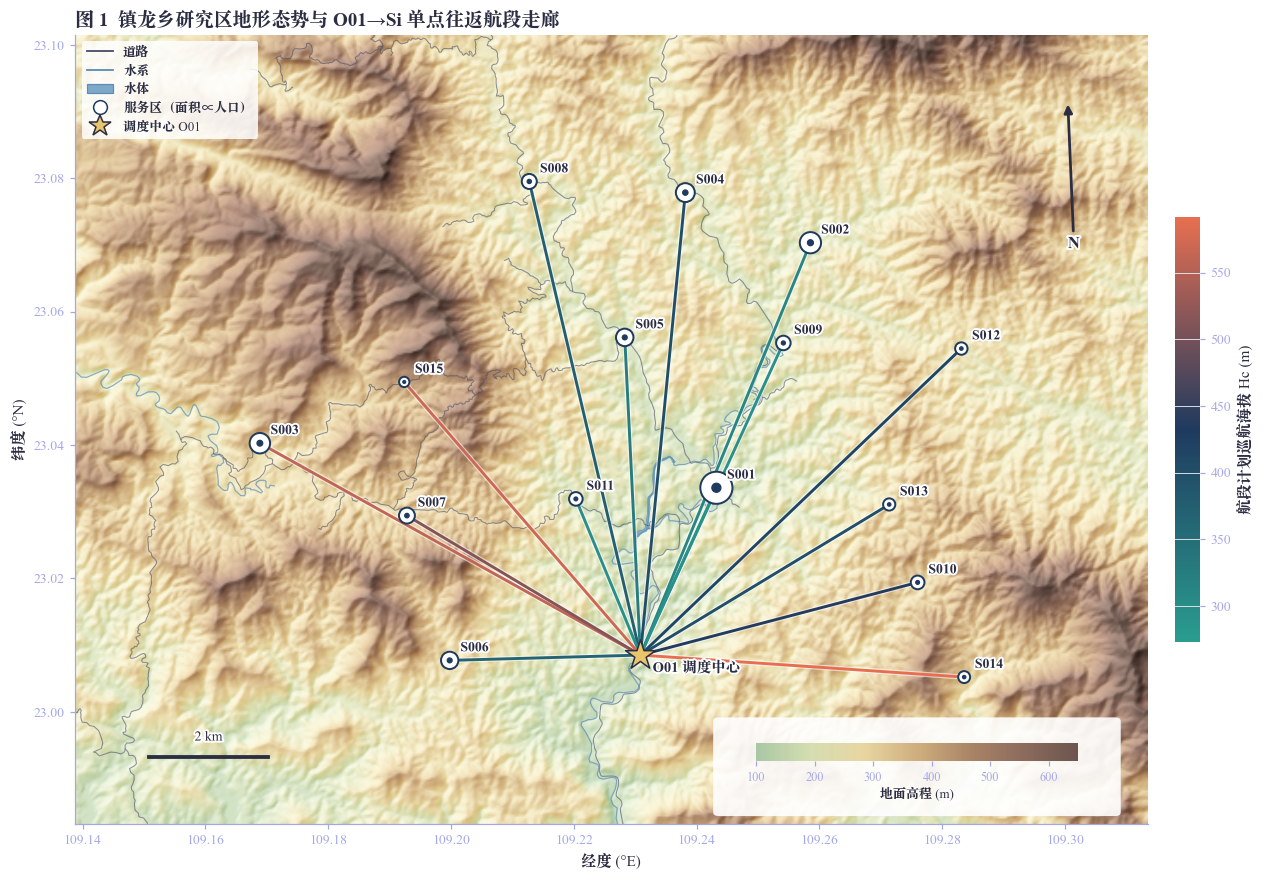

In [6]:
# ---------- 截取 DEM 到研究区 ----------
pad_lon, pad_lat = 0.030, 0.022
lon_min, lon_max = min(areas.lon.min(), LON_O) - pad_lon, max(areas.lon.max(), LON_O) + pad_lon
lat_min, lat_max = min(areas.lat.min(), LAT_O) - pad_lat, max(areas.lat.max(), LAT_O) + pad_lat
c0, c1 = np.searchsorted(LON_C, [lon_min, lon_max])
r1, r0 = NROW - np.searchsorted(LAT_C[::-1], [lat_min, lat_max])
sub = DEM[r0:r1, c0:c1]
extent = [GEO['lon0'] + c0*GEO['dx'], GEO['lon0'] + c1*GEO['dx'], GEO['lat0'] - r1*GEO['dy'], GEO['lat0'] - r0*GEO['dy']]
mean_lat = (lat_min + lat_max)/2
ASPECT = 1/math.cos(math.radians(mean_lat))
m_per_deg_lon = dist_m(LON_O, LAT_O, LON_O + 0.01, LAT_O)/0.01
cmap_hypso = LinearSegmentedColormap.from_list('hypso',['#A9C7A5','#D5DDB0','#E8D6A2','#CFAE7E','#A98466','#8C6B5D','#6B564D'])
ls = LightSource(azdeg=315,altdeg=40)
rgb = ls.shade(np.nan_to_num(sub,nan=np.nanmin(sub)),cmap=cmap_hypso,blend_mode='soft',vert_exag=1.5,
               dx=GEO['dx']*m_per_deg_lon,dy=GEO['dy']*111132.0,vmin=100,vmax=650)
fig = plt.figure(figsize=(12.5,9.2))
ax = fig.add_axes([0.05,0.06,0.78,0.9])
ax.imshow(rgb,extent=extent,aspect=ASPECT,interpolation='bilinear',zorder=0)
ax.grid(False)
# 水体（面）与水系（线）
polys = [grp[['经度','纬度']].values for _,grp in water.groupby(['水体要素编号','多边形编号','环编号'])]
ax.add_collection(PolyCollection(polys,facecolors='#7FA8C9',edgecolors='#5B8DB8',linewidths=.4,alpha=.85,zorder=1))
ax.add_collection(LineCollection([grp[['经度','纬度']].values for _,grp in rivers.groupby('水系要素编号')],colors='#5B8DB8',linewidths=.8,alpha=.7,zorder=2))
# 道路（线）：高速/国省道稍粗一点
rd_segs,rd_lw=[],[]
for _,grp in roads.groupby('道路要素编号'):
    rd_segs.append(grp[['经度','纬度']].values)
    rd_lw.append(1.5 if grp['道路类型'].iloc[0] in ('高速公路','国道','省道') else .7)
ax.add_collection(LineCollection(rd_segs,colors='#4A4E69',linewidths=rd_lw,alpha=.6,zorder=2))
# 航段走廊，颜色 = 巡航海拔
Hc_vals=np.array([SEG[i]['Hc'] for i in AREA_IDS]); norm_Hc=Normalize(Hc_vals.min(),Hc_vals.max())
for r in areas.itertuples():
    col=CMAP_SEQ(norm_Hc(SEG[r.id]['Hc']))
    ax.plot([LON_O,r.lon],[LAT_O,r.lat],color='white',lw=3.4,alpha=.6,zorder=3,solid_capstyle='round')
    ax.plot([LON_O,r.lon],[LAT_O,r.lat],color=col,lw=1.9,zorder=4,solid_capstyle='round')
# 服务区：面积 ∝ 人口
sizes=30+9*np.sqrt(areas['pop'])
ax.scatter(areas.lon,areas.lat,s=sizes,facecolor='white',edgecolor=PAL['indigo'],linewidths=1.3,zorder=6)
ax.scatter(areas.lon,areas.lat,s=sizes*.08,color=PAL['indigo'],zorder=7)
for r in areas.itertuples():
    ax.annotate(r.id,(r.lon,r.lat),xytext=(7,6),textcoords='offset points',fontsize=9,fontweight='bold',color=PAL['ink'],path_effects=HALO,zorder=8)
ax.scatter([LON_O],[LAT_O],s=420,marker='*',color=PAL['gold'],edgecolor=PAL['ink'],linewidths=1,zorder=9)
ax.annotate('O01 调度中心',(LON_O,LAT_O),xytext=(8,-11),textcoords='offset points',fontsize=9.5,fontweight='bold',path_effects=HALO,zorder=10)
# 比例尺、指北针
sb_len=2000/m_per_deg_lon
x_sb,y_sb=extent[0]+.012,extent[2]+.010
ax.plot([x_sb,x_sb+sb_len],[y_sb,y_sb],color=PAL['ink'],lw=2.5,zorder=10)
ax.text(x_sb+sb_len/2,y_sb+.0025,'2 km',ha='center',fontsize=9,path_effects=HALO,zorder=10)
ax.annotate('N',xy=(extent[1]-.013,extent[3]-.010),xytext=(extent[1]-.012,extent[3]-.032),ha='center',fontsize=11,fontweight='bold',arrowprops=dict(arrowstyle='-|>',color=PAL['ink'],lw=1.8),path_effects=HALO,zorder=10)
ax.set_xlim(extent[0],extent[1]); ax.set_ylim(extent[2],extent[3])
ax.set_xlabel('经度 (°E)'); ax.set_ylabel('纬度 (°N)')
ax.set_title('图 1  镇龙乡研究区地形态势与 O01→Si 单点往返航段走廊',loc='left',fontsize=12.5)
# 色带：巡航海拔（右侧竖）与高程（图内右下横，白色底板）
cax1=fig.add_axes([.85,.30,.018,.42])
cb1=fig.colorbar(mpl.cm.ScalarMappable(norm=norm_Hc,cmap=CMAP_SEQ),cax=cax1)
cb1.set_label('航段计划巡航海拔 Hc (m)'); cb1.outline.set_visible(False)
ax.add_patch(FancyBboxPatch((.60,.015),.37,.115,boxstyle='round,pad=0.005',transform=ax.transAxes,facecolor='white',edgecolor='none',alpha=.9,zorder=4))
cax2=ax.inset_axes([.635,.080,.30,.022],zorder=5)
cb2=fig.colorbar(mpl.cm.ScalarMappable(norm=Normalize(100,650),cmap=cmap_hypso),cax=cax2,orientation='horizontal')
cb2.set_label('地面高程 (m)',fontsize=8.5,labelpad=2); cb2.ax.tick_params(labelsize=8); cb2.outline.set_visible(False); cax2.grid(False)
handles=[Line2D([],[],color='#4A4E69',lw=1.2,label='道路'),Line2D([],[],color='#5B8DB8',lw=1.2,label='水系'),
         Rectangle((0,0),1,1,facecolor='#7FA8C9',edgecolor='#5B8DB8',label='水体'),
         Line2D([],[],marker='o',markerfacecolor='white',markeredgecolor=PAL['indigo'],color='none',markersize=9,label='服务区（面积∝人口）'),
         Line2D([],[],marker='*',color=PAL['gold'],markeredgecolor=PAL['ink'],markersize=15,linestyle='none',label='调度中心 O01')]
ax.legend(handles=handles,loc='upper left',fontsize=8.5,frameon=True,framealpha=.85,edgecolor='none')
savefig(fig,'图01_研究区地形态势与航段走廊'); plt.show()

## 8 图 2：各服务区航段地形剖面与三阶段飞行包线

依次展示 15 个服务区的地形剖面、沿线最高地面像元、巡航海拔及服务区作业高度。

↳ 已生成 图02_航段地形剖面与飞行包线.png（嵌入 Notebook；运行时将保存至配置目录）


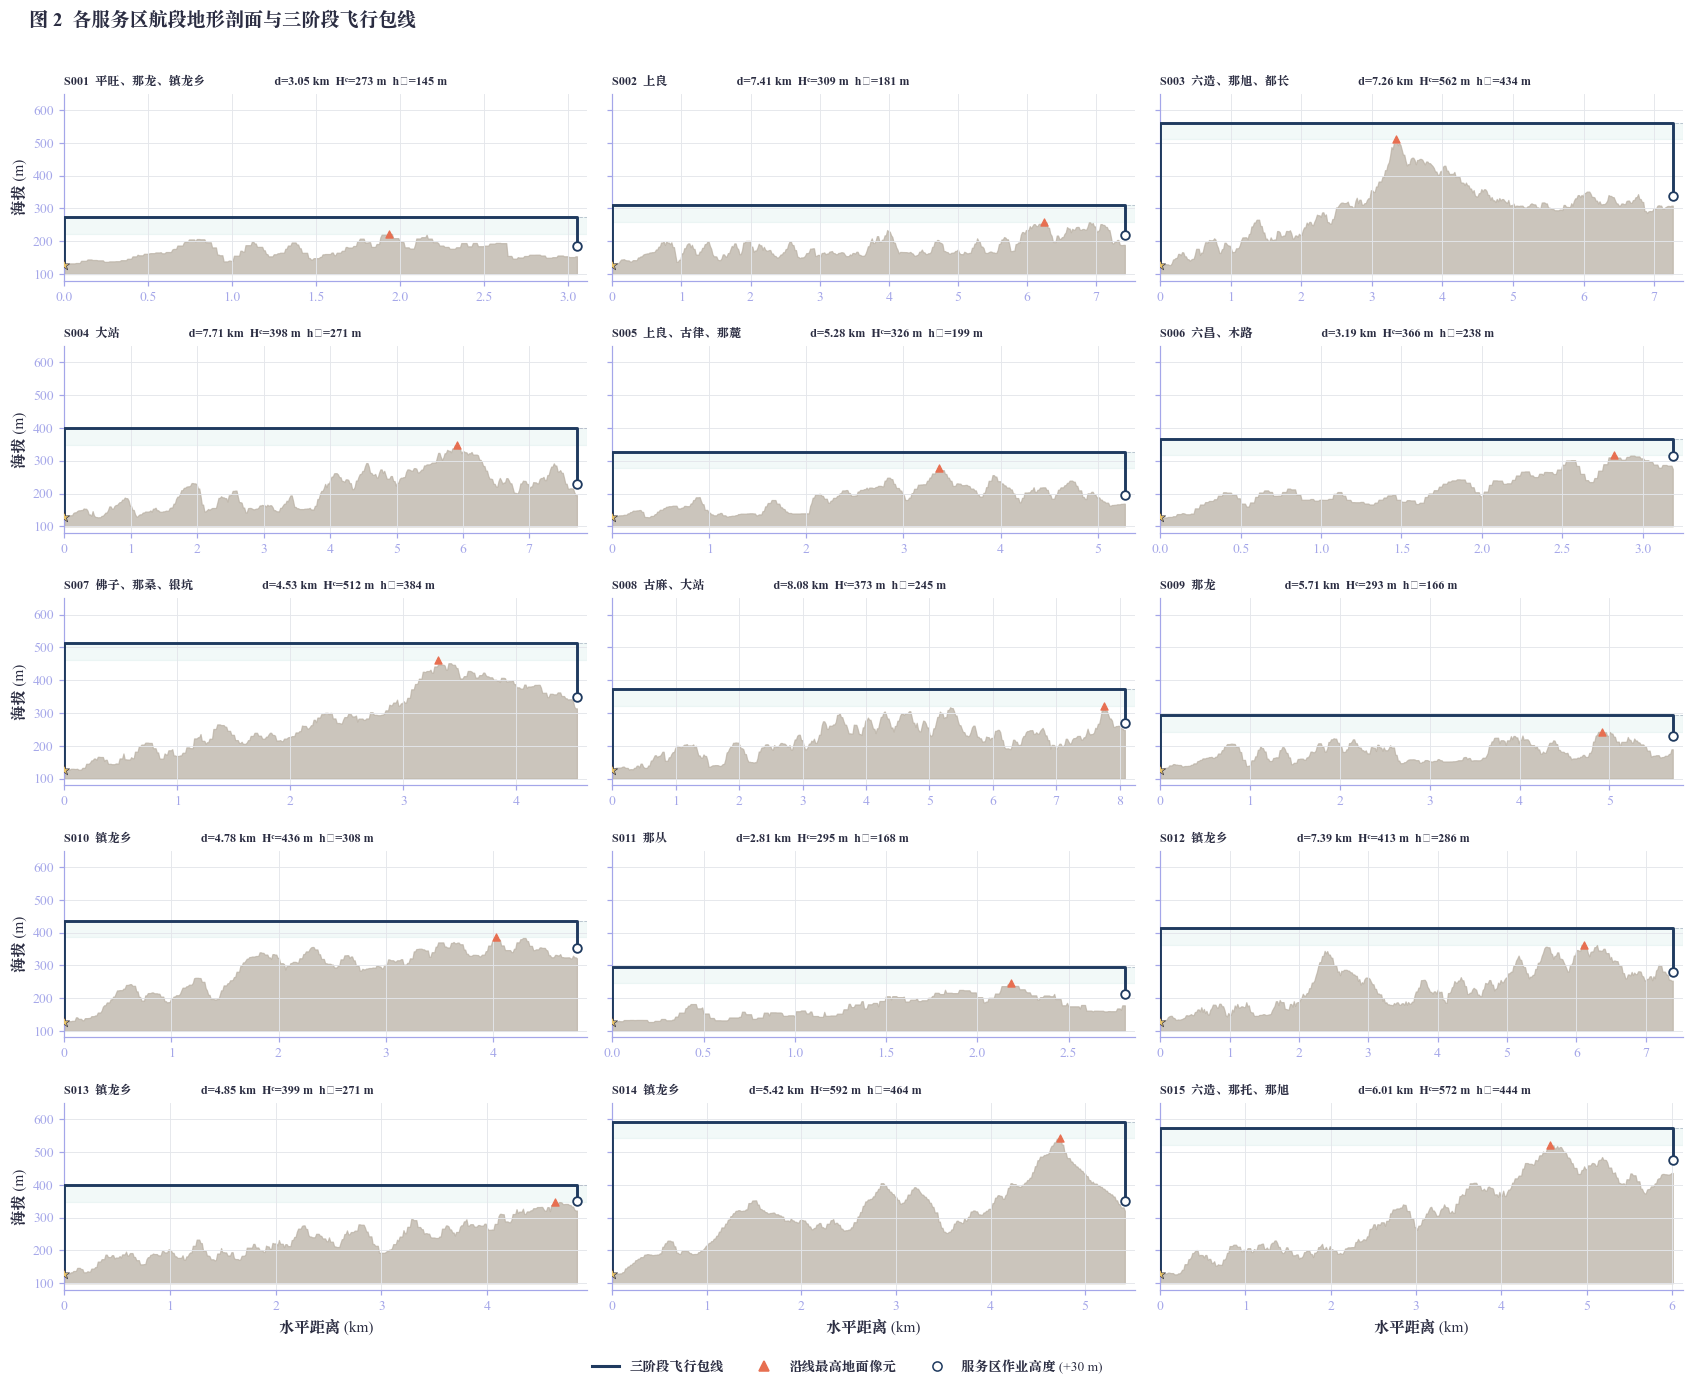

In [7]:
fig, axes = plt.subplots(5,3,figsize=(15.5,12.5),sharey=True)
for ax,r in zip(axes.flat,areas.itertuples()):
    g=SEG[r.id]; x=np.linspace(0,g['d']/1000,len(g['profile']))
    ax.fill_between(x,g['profile'],100,color=PAL['sand'],alpha=.72,zorder=1)
    ax.axhspan(g['Hc']-50,g['Hc'],color=PAL['teal'],alpha=.06,zorder=0)
    ax.plot([0,0,x[-1],x[-1]],[Z_O,g['Hc'],g['Hc'],r.elev+H_SERVICE],color=PAL['indigo'],lw=1.9,zorder=3)
    ax.axhline(g['Hc'],color=PAL['grey'],ls='--',lw=.6,alpha=.55)
    ax.scatter([g['s_max']/1000],[g['zmax']],marker='^',s=22,color=PAL['coral'],zorder=4)
    ax.scatter([0],[Z_O],marker='*',s=50,color=PAL['gold'],edgecolor=PAL['ink'],lw=.4,zorder=5)
    ax.scatter([x[-1]],[r.elev+H_SERVICE],marker='o',s=32,facecolor='white',edgecolor=PAL['indigo'],lw=1.2,zorder=5)
    ax.set_title(f'{r.id}  {r.name}                       d={g["d"]/1000:.2f} km  Hᶜ={g["Hc"]:.0f} m  h⁺={g["hup_out"]:.0f} m',loc='left',fontsize=8)
    ax.set_xlim(0,x[-1]*1.02); ax.set_ylim(80,650)
for ax in axes[:,0]: ax.set_ylabel('海拔 (m)')
for ax in axes[-1]: ax.set_xlabel('水平距离 (km)')
handles=[Line2D([],[],color=PAL['indigo'],lw=2,label='三阶段飞行包线'),Line2D([],[],marker='^',linestyle='none',color=PAL['coral'],label='沿线最高地面像元'),
         Line2D([],[],marker='o',markerfacecolor='white',markeredgecolor=PAL['indigo'],linestyle='none',label='服务区作业高度 (+30 m)')]
fig.legend(handles=handles,loc='lower center',ncol=3,bbox_to_anchor=(.5,-.005),fontsize=8.8)
fig.suptitle('图 2  各服务区航段地形剖面与三阶段飞行包线',x=.02,ha='left',fontsize=12.5,fontweight='bold',y=.995)
fig.tight_layout(rect=[0,.02,1,.985],h_pad=1.6)
savefig(fig,'图02_航段地形剖面与飞行包线'); plt.show()

## 9 时间-能耗模型与最大安全载荷

### 9.1 模型实现

按第 3 节公式实现 `L_eq / E_hor / E_up / sortie_energy / sortie_time`，所有函数都以**机型参数行 + 航段几何字典 + 载荷/箱数**为输入，问题二、三可直接复用（多点航线只需把“航段”换成相邻节点对）。

### 9.2 最大安全载荷的定义与求解

$$q_{gi}^{\max}=\max\left\{q\in[0,Q_g]:E_{gi}(q)\leq(1-\rho_g)E_g^{use}\right\}.$$

由于 $E_{gi}(q)$ 关于 $q$ **严格单调递增**，解只有三种情形：

- $E_{gi}(Q_g)\leq(1-\rho_g)E_g^{use}$：能量充裕，$q^{\max}=Q_g$，**结构载荷约束起作用**；
- $E_{gi}(0)>(1-\rho_g)E_g^{use}$：空载往返都不满足安全余量，该机型对该服务区**不可行**；
- 其余：$q^{\max}$ 为方程 $E_{gi}(q)=(1-\rho_g)E_g^{use}$ 在 $[0,Q_g]$ 上的唯一根，用**二分法求解**（60 次迭代后区间宽度 $<Q_g/2^{60}$，远小于 1 g，精度充足）。

注意 $q^{\max}$ **只由能量决定**；装载体积是组批阶段的另一条独立约束（例如机型 A 的 0.06 m³ 只能装 2 箱饮用水，体积往往先于质量成为瓶颈）。

In [8]:
G0=9.81
def L_eq(p,q): return p.L0-(p.L0-p.LF)*(q/p.Q)**1.5
def E_hor(p,d,q): return d*p.E_use/L_eq(p,q)
def E_up(p,h_up,q): return (p.m0+q)*G0*h_up/(p.eta_up*3.6e6)
def leg_time(p,d,h_up,h_dn): return h_up/p.v_up+d/p.v_c+h_dn/p.v_dn
def sortie_energy_parts(p,g,q):
    return (E_hor(p,g['d'],q),E_up(p,g['hup_out'],q),
            E_hor(p,g['d'],0),E_up(p,g['hup_ret'],0))
def sortie_energy(p,g,q): return sum(sortie_energy_parts(p,g,q))
def sortie_flight_time(p,g):
    return leg_time(p,g['d'],g['hup_out'],g['hdn_out'])+leg_time(p,g['d'],g['hup_ret'],g['hdn_ret'])
def sortie_time(p,g,n_box):
    return p.t_prep+n_box*p.t_load+sortie_flight_time(p,g)+p.t_hand+n_box*p.t_box
def max_safe_payload(p,g,rho=None,iters=60):
    rho=p.rho if rho is None else rho; budget=(1-rho)*p.E_use
    if sortie_energy(p,g,0)>budget+1e-12: return float('nan'),'不可行'
    if sortie_energy(p,g,p.Q)<=budget+1e-12: return float(p.Q),'结构载荷'
    lo,hi=0.0,float(p.Q)
    for _ in range(iters):
        mid=(lo+hi)/2
        if sortie_energy(p,g,mid)<=budget: lo=mid
        else: hi=mid
    return lo,'能量'
def compute_qmax(rho_map=None):
    q=pd.DataFrame(index=AREA_IDS,columns=TYPES,dtype=float); b=q.copy().astype(object)
    for name in TYPES:
        p=uav.loc[name]; rho=None if rho_map is None else rho_map[name]
        for a in AREA_IDS: q.loc[a,name],b.loc[a,name]=max_safe_payload(p,SEG[a],rho)
    return q,b

QMAX,QBIND=compute_qmax()
tbl=QMAX.round(2).astype(str)+' ('+QBIND.replace({'结构载荷':'结构','能量':'能量','不可行':'×'})+')'
tbl.insert(0,'距离_km',(seg_df.d/1000).round(2)); tbl.insert(1,'巡航海拔_m',seg_df.Hc.round(0))
display(tbl)
parts=[]
for name in TYPES:
    for a in AREA_IDS:
        q=QMAX.loc[a,name]
        if pd.notna(q):
            eh1,eu1,eh2,eu2=sortie_energy_parts(uav.loc[name],SEG[a],q)
            parts.append(dict(area=a,model=name,out_hor=eh1,out_up=eu1,ret_hor=eh2,ret_up=eu2))
energy_parts_df=pd.DataFrame(parts)


,距离_km,巡航海拔_m,A,B,C
S001,3.05,273.0,25.0 (结构),30.0 (结构),80.0 (结构)
S002,7.41,309.0,25.0 (结构),30.0 (结构),68.86 (能量)
S003,7.26,562.0,25.0 (结构),30.0 (结构),68.21 (能量)
S004,7.71,398.0,25.0 (结构),30.0 (结构),63.7 (能量)
S005,5.28,326.0,25.0 (结构),30.0 (结构),80.0 (结构)
S006,3.19,366.0,25.0 (结构),30.0 (结构),80.0 (结构)
S007,4.53,512.0,25.0 (结构),30.0 (结构),80.0 (结构)
S008,8.08,373.0,25.0 (结构),28.8 (能量),58.9 (能量)
S009,5.71,293.0,25.0 (结构),30.0 (结构),80.0 (结构)
S010,4.78,436.0,25.0 (结构),30.0 (结构),80.0 (结构)


## 10 图 3、图 4：能量预算曲线与最大安全载荷图谱

**图 3（能量预算曲线）：** 每个机型一幅，横轴载荷、纵轴架次总能耗 $E_{gi}(q)$。15 条曲线按距离着色，水平红线为能量预算 $(1-\rho_g)E_g^{use}$。曲线与预算线的交点就是 $q^{\max}$——曲线到达 $Q_g$ 之前就触线的服务区，能量约束起作用（实心点），否则结构载荷起作用（空心点）。(d) 用 S003 演示 $E(q)$ 的凸性：C 型两架次总质量固定为 81 kg 时，总能耗在均分载荷处最小，极端分配最大，这是后续组批模型自动选择均衡分载的原因。

**图 4（载荷图谱）：** 左图为 15×3 的“点阵热力图”，点的面积和颜色 $\propto q^{\max}$，红色描边表示能量约束起作用；右图把 $q^{\max}$ 画在水平距离上，并叠加“零起伏理想地形”（两段爬升均只有 50 m 净空）下的理论包线，实际点与包线之间的竖线即地形爬升惩罚。

↳ 已生成 图03_能量预算曲线.png（嵌入 Notebook；运行时将保存至配置目录）


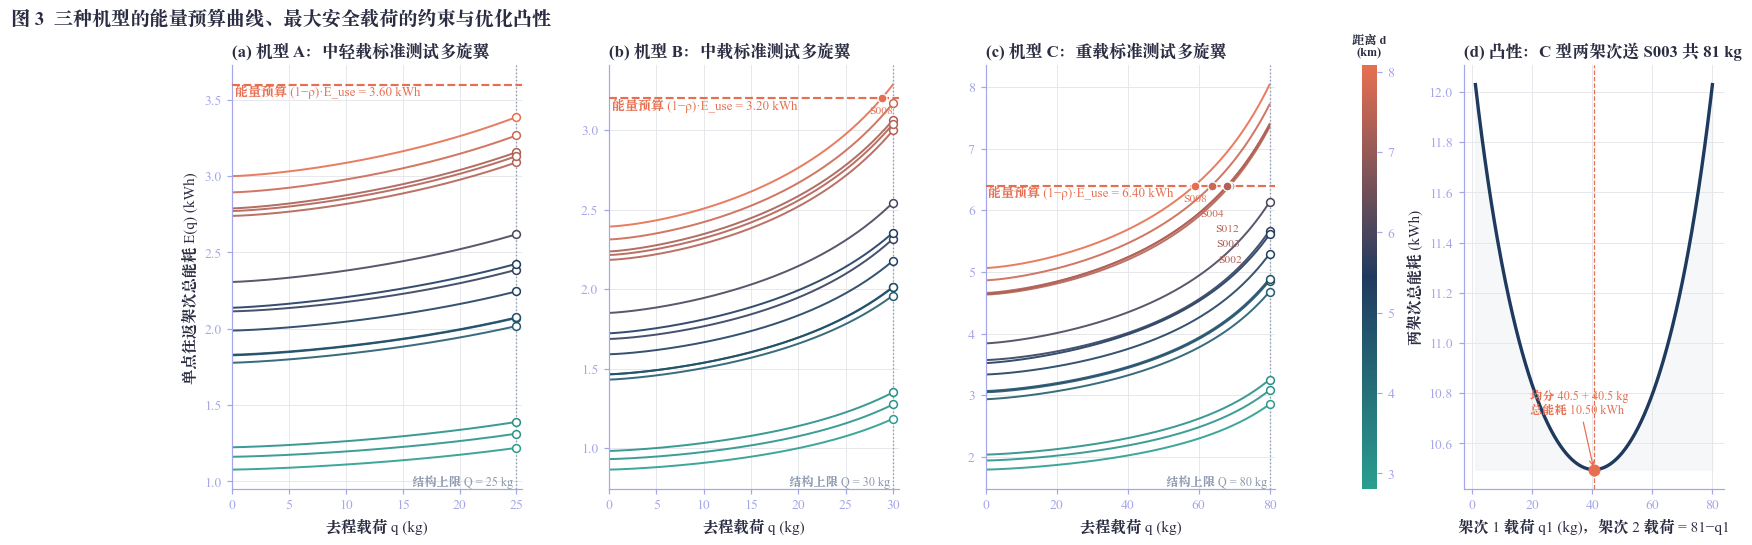

In [9]:
d_vals=np.array([SEG[a]['d'] for a in AREA_IDS]); norm_d=Normalize(d_vals.min()/1000,d_vals.max()/1000)
fig=plt.figure(figsize=(17.5,5.0)); gs=fig.add_gridspec(1,5,width_ratios=[1,1,1,.05,.9],wspace=.38)
axes=[fig.add_subplot(gs[k]) for k in range(3)]
for ax,gname in zip(axes,TYPES):
    p=uav.loc[gname]; qs=np.linspace(0,p.Q,200); budget=(1-p.rho)*p.E_use
    labelled=[]
    for a in AREA_IDS:
        col=CMAP_SEQ(norm_d(SEG[a]['d']/1000))
        ax.plot(qs,[sortie_energy(p,SEG[a],q) for q in qs],color=col,lw=1.3,alpha=.9)
        qm,bind=QMAX.loc[a,gname],QBIND.loc[a,gname]
        if bind=='能量':
            ax.scatter([qm],[budget],s=34,color=col,edgecolor='white',lw=.8,zorder=5); labelled.append((qm,a,col))
        else:
            ax.scatter([qm],[sortie_energy(p,SEG[a],qm)],s=26,facecolor='white',edgecolor=col,lw=1,zorder=5)
    labelled.sort(); k_stack=0
    for j,(qm,a,col) in enumerate(labelled):
        k_stack=k_stack+1 if j>0 and qm-labelled[j-1][0]<.06*p.Q else 0
        ax.annotate(a,(qm,budget),xytext=(0,-10-10*k_stack),textcoords='offset points',fontsize=7.6,ha='center',color=col)
    ax.axhline(budget,color=PAL['coral'],lw=1.4,ls='--',zorder=4)
    ax.text(.01*p.Q,budget,f'能量预算 (1−ρ)·E_use = {budget:.2f} kWh',fontsize=8.5,color=PAL['coral'],va='top')
    ax.axvline(p.Q,color=PAL['grey'],lw=.9,ls=':')
    ax.text(p.Q*.99,ax.get_ylim()[0],f'结构上限 Q = {p.Q:.0f} kg',ha='right',va='bottom',fontsize=8,color=PAL['grey'])
    ax.set_title(f'({"abc"[TYPES.index(gname)]}) 机型 {gname}：{p["name"]}',loc='left')
    ax.set_xlabel('去程载荷 q (kg)'); ax.set_xlim(0,p.Q*1.02)
axes[0].set_ylabel('单点往返架次总能耗 E(q) (kWh)')
cax=fig.add_subplot(gs[3]); cax.grid(False)
cb=fig.colorbar(mpl.cm.ScalarMappable(norm=norm_d,cmap=CMAP_SEQ),cax=cax); cb.outline.set_visible(False); cax.set_title('距离 d\n(km)',fontsize=8)
# (d) 凸性 → 均衡分载
ax=fig.add_subplot(gs[4]); pC=uav.loc['C']; a_demo='S003'; M_tot=boxes[boxes.area==a_demo].mass.sum()
q1=np.linspace(max(0,M_tot-pC.Q),min(pC.Q,M_tot),300)
Etot=np.array([sortie_energy(pC,SEG[a_demo],q)+sortie_energy(pC,SEG[a_demo],M_tot-q) for q in q1])
ax.plot(q1,Etot,color=PAL['indigo'],lw=2.2)
ax.fill_between(q1,Etot,Etot.min(),color=PAL['indigo'],alpha=.04)
ax.axvline(M_tot/2,color=PAL['coral'],lw=.8,ls='--')
ax.scatter([M_tot/2],[Etot.min()],s=50,color=PAL['coral'],zorder=5)
ax.annotate(f'均分 {M_tot/2:.1f} + {M_tot/2:.1f} kg\n总能耗 {Etot.min():.2f} kWh',(M_tot/2,Etot.min()),xytext=(-42,37),textcoords='offset points',fontsize=8,color=PAL['coral'],arrowprops=dict(arrowstyle='->',color=PAL['coral']))
ax.set_title('(d) 凸性：C 型两架次送 S003 共 81 kg',loc='left'); ax.set_xlabel('架次 1 载荷 q1 (kg)，架次 2 载荷 = 81−q1'); ax.set_ylabel('两架次总能耗 (kWh)')
fig.suptitle('图 3  三种机型的能量预算曲线、最大安全载荷的约束与优化凸性',x=.01,ha='left',fontsize=12.5,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.94]); savefig(fig,'图03_能量预算曲线'); plt.show()

↳ 已生成 图04_最大安全载荷图谱.png（嵌入 Notebook；运行时将保存至配置目录）


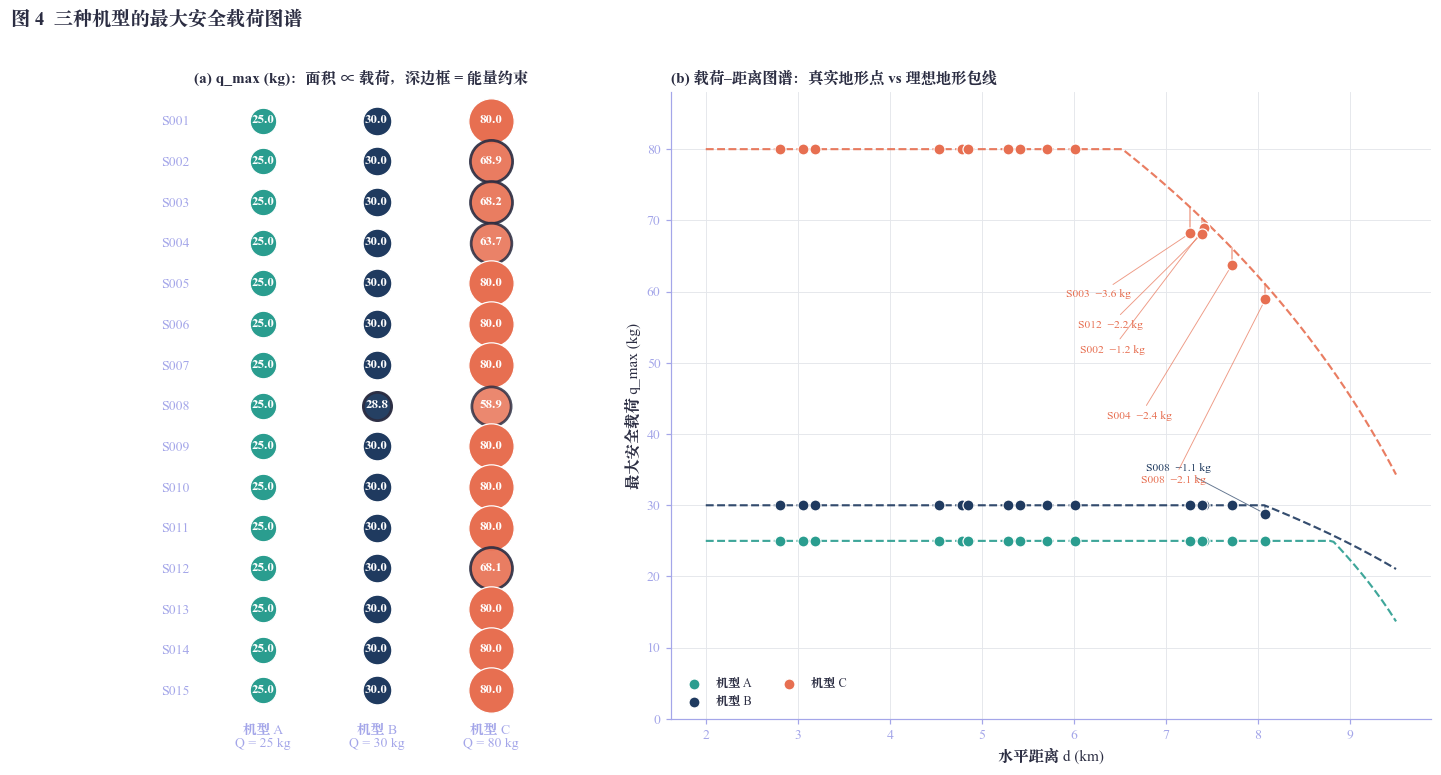

In [10]:
fig=plt.figure(figsize=(14.5,7.4)); gs=fig.add_gridspec(1,2,width_ratios=[.72,1.5],wspace=.2)
# (a) 点阵热力图：面积 ∝ q_max，颜色 = 机型，透明度 ∝ q_max/Q_g
ax=fig.add_subplot(gs[0]); ax.grid(False)
ymap={a:k for k,a in enumerate(AREA_IDS[::-1])}
for j,gname in enumerate(TYPES):
    p=uav.loc[gname]
    for a in AREA_IDS:
        q=QMAX.loc[a,gname]; frac=0 if np.isnan(q) else q/p.Q; eb=QBIND.loc[a,gname]=='能量'
        ax.scatter(j,ymap[a],s=0 if np.isnan(q) else 40+10.5*q,color=TYPE_COLOR[gname],alpha=.35+.65*frac,
                   edgecolor=PAL['ink'] if eb else 'white',linewidths=1.8 if eb else .8,zorder=3)
        ax.text(j,ymap[a],'×' if np.isnan(q) else f'{q:.1f}',ha='center',va='center',fontsize=8.5,color='white',fontweight='bold',zorder=4)
ax.set_xticks(range(len(TYPES))); ax.set_xticklabels([f'机型 {g}\nQ = {uav.loc[g,"Q"]:.0f} kg' for g in TYPES])
ax.set_yticks(range(len(AREA_IDS))); ax.set_yticklabels(AREA_IDS[::-1]); ax.set_xlim(-.6,len(TYPES)-.4); ax.set_ylim(-.7,len(AREA_IDS)-.3)
for s in ['left','bottom']: ax.spines[s].set_visible(False)
ax.tick_params(length=0); ax.set_title('(a) q_max (kg)：面积 ∝ 载荷，深边框 = 能量约束',loc='left',fontsize=10)
# (b) 距离–载荷图谱
ax=fig.add_subplot(gs[1]); d_grid=np.linspace(2000,9500,200)
for gname in TYPES:
    p=uav.loc[gname]; col=TYPE_COLOR[gname]
    env=[max_safe_payload(p,dict(d=dd,hup_out=CLEARANCE,hup_ret=CLEARANCE))[0] for dd in d_grid]
    ax.plot(d_grid/1000,env,color=col,lw=1.4,ls='--',alpha=.9)
    xs=np.array([SEG[a]['d']/1000 for a in AREA_IDS]); ys=np.array([QMAX.loc[a,gname] for a in AREA_IDS])
    ax.scatter(xs,ys,s=52,color=col,edgecolor='white',lw=.8,zorder=5,label=f'机型 {gname}')
    pen=[]
    for a,x,y in zip(AREA_IDS,xs,ys):
        e=max_safe_payload(p,dict(d=SEG[a]['d'],hup_out=CLEARANCE,hup_ret=CLEARANCE))[0]
        if np.isfinite(e) and e-y>.5:
            ax.plot([x,x],[y,e],color=col,lw=1,alpha=.6,zorder=4); pen.append((x,y,e,a))
    pen.sort()
    for j,(x,y,e,a) in enumerate(pen):
        ax.annotate(f'{a}  −{e-y:.1f} kg',(x,y),xytext=(x-1.35,y-9-4.2*j) if gname=='C' else (x-1.3,y+6),textcoords='data',fontsize=7.6,color=col,
                    arrowprops=dict(arrowstyle='-',color=col,lw=.6,alpha=.7))
ax.set_xlabel('水平距离 d (km)'); ax.set_ylabel('最大安全载荷 q_max (kg)'); ax.set_ylim(0,88)
ax.legend(loc='lower left',ncol=2,fontsize=8)
ax.set_title('(b) 载荷–距离图谱：真实地形点 vs 理想地形包线',loc='left',fontsize=10)
fig.suptitle('图 4  三种机型的最大安全载荷图谱',x=.01,ha='left',fontsize=12.5,fontweight='bold')
savefig(fig,'图04_最大安全载荷图谱'); plt.show()

## 11 货箱组批模型：装载模式枚举 + 多目标动态规划

### 11.1 建模思路

同一服务区内、同类货箱（同物资类型）的质量、体积完全相同，因此**一个架次装什么只取决于四类物资的箱数向量** $\boldsymbol n=(n_{MED},n_{WAT},n_{FOD},n_{HYG})$，而与具体箱号无关。于是把“把 80 个箱子分到若干架次”这一组合爆炸的问题，压缩为：

- **装载模式** $\pi=(g,\boldsymbol n)$：机型 $g$ 装载箱数向量 $\boldsymbol n$，可行当且仅当

$$\sum_k n_km_k\leq q_{gi}^{\max},\qquad\sum_kn_kv_k\leq V_g,\qquad 0\leq\boldsymbol n\leq\boldsymbol r_i.$$

其中 $\boldsymbol r_i$ 为服务区 $i$ 的需求箱数向量。载质量上限已隐含能量安全余量（第 9 节的单调性保证二者等价）。

- **模式的代价向量** $\boldsymbol c_\pi=(1,E_{gi}(\sum_k n_km_k),T_{gi}(\sum_k n_k))$，三个分量分别对应架次、能耗、作业时间。

### 11.2 整数规划形式（论文表述）

设 $x_\pi\in\mathbb Z_{\geq0}$ 为模式 $\pi$ 的使用次数，服务区 $i$ 的组批问题为多目标整数规划

$$\min_x\left(\sum_\pi x_\pi,\ \sum_\pi E_\pi x_\pi,\ \sum_\pi T_\pi x_\pi\right)\quad\mathrm{s.t.}\quad\sum_\pi\boldsymbol n_\pi x_\pi=\boldsymbol r_i,\quad x_\pi\in\mathbb Z_{\geq0}.$$

### 11.3 求解：剩余需求上的多目标动态规划（精确 Pareto 前沿）

状态 = 剩余需求向量 $\boldsymbol r$（S001 最多 $3\times9\times4\times3=324$ 个状态），递推

$$F(\boldsymbol r)=\operatorname{Pareto}\left\{\boldsymbol c_\pi+\boldsymbol f:\pi\text{ 可行},\ \boldsymbol n_\pi\leq\boldsymbol r,\ \boldsymbol f\in F(\boldsymbol r-\boldsymbol n_\pi)\right\},\qquad F(\boldsymbol0)=\{(0,0,0)\}.$$

Pareto{·} 保留非支配向量（$a$ 支配 $b$ 当且仅当 $a\leq b$ 且至少一个分量严格小）。因为代价可加、目标单调，子结构最优性成立，递推得到的 $F(\boldsymbol r_i)$ 就是该服务区完整、精确的 Pareto 前沿，不依赖任何权重。三维非支配判定采用“按架次分层 + 每层能耗排序 + 前缀最小时间”的 $O(k\log k)$ 过滤。每个前沿点保存回溯指针，可还原出具体的模式序列，再把箱号按“首批保障优先”的顺序落到架次上。

### 11.4 从 Pareto 前沿到决策：优先关系与权衡

问题一要求“综合考虑三指标并说明权衡或优先关系”。我们在前沿上定义四种决策规则：

| 规则 | 含义 | 应急场景解释 |
| --- | --- | --- |
| **R1 架次优先** | 字典序 $N\rightarrow E\rightarrow T$，架次少 $\Rightarrow$ 占用无人机与电池周转少，是后续问题二、三资源约束下最关键的指标 | 首选 |
| R2 能耗优先 | $E\rightarrow N\rightarrow T$ | 能源受限（断电场景）时优先 |
| R3 时间优先 | $T\rightarrow N\rightarrow E$ | 作业窗口紧张时优先 |
| R4 均衡折中 | 以各指标全局理想值归一化后等权求和 | 无明显偏好时的折中 |

若四条规则给出同一方案，说明三指标不冲突；若出现分歧，就用差异刻画权衡。除此之外还比较“只用 A / 只用 B / 只用 C / A+B”四种机型策略，量化重载机型 C 的价值。

## 12 求解：各服务区 Pareto 前沿、四种决策规则与机型策略比较

In [11]:
def pareto_filter(cands,eps=1e-9):
    """按 N、E 排序，用每层的前缀最小 T 筛除三目标支配点。候选前 3 项为 N/E/T。"""
    cands.sort(key=lambda c:(c[0],c[1],c[2]))
    layers={}; kept=[]
    for c in cands:
        N,E,T=c[:3]; dominated=False
        for level,(Es,Ts) in layers.items():
            if level>N: continue
            k=bisect.bisect_right(Es,E+eps)
            if k and Ts[k-1]<=T+eps:
                dominated=True; break
        if dominated: continue
        kept.append(c)
        Es,Ts=layers.setdefault(N,([],[]))
        Es.append(E); Ts.append(min(T,Ts[-1]) if Ts else T)
    return kept

class AreaBatching:
    def __init__(self,area_id,qmax_row,allowed=None):
        self.area=area_id; self.geom=SEG[area_id]
        b=boxes[boxes.area==area_id]
        cls=(b.groupby('mat').agg(mass=('mass','first'),vol=('vol','first'),n=('box','size'))
             .reindex(MAT_ORDER).dropna())
        self.mats=cls.index.tolist(); self.m=cls.mass.to_numpy(); self.v=cls.vol.to_numpy()
        self.r0=tuple(int(x) for x in cls.n.to_numpy())
        self.allowed=TYPES if allowed is None else list(allowed)
        candidates=[]
        for name in self.allowed:
            p=uav.loc[name]; cap=qmax_row[name]
            if pd.isna(cap): continue
            for nvec in itertools.product(*(range(x+1) for x in self.r0)):
                if not any(nvec): continue
                mass=float(np.dot(nvec,self.m)); vol=float(np.dot(nvec,self.v))
                if mass<=cap+1e-9 and vol<=p.V+1e-9:
                    candidates.append(dict(g=name,n=nvec,mass=mass,vol=vol,nbox=sum(nvec),
                                           E=sortie_energy(p,self.geom,mass),
                                           T=sortie_time(p,self.geom,sum(nvec))))
        # 同箱数向量仅保留时间/能耗 Pareto 模式。
        by={}
        for pt in candidates: by.setdefault(pt['n'],[]).append(pt)
        self.pats=[]
        for group in by.values():
            for j,p in enumerate(group):
                dom=any(o['E']<=p['E']+1e-9 and o['T']<=p['T']+1e-9 and
                        (o['E']<p['E']-1e-9 or o['T']<p['T']-1e-9 or k<j)
                        for k,o in enumerate(group) if k!=j)
                if not dom: self.pats.append(p)
        zero=(0,)*len(self.r0)
        self.memo={zero:[(0,0.0,0.0,None)]}
        self.front=self._F(self.r0) if self.pats else []

    def _F(self,r):
        if r in self.memo: return self.memo[r]
        cands=[]
        for pid,pt in enumerate(self.pats):
            if all(n<=ri for n,ri in zip(pt['n'],r)):
                child=tuple(ri-n for n,ri in zip(pt['n'],r))
                for idx,c in enumerate(self._F(child)):
                    cands.append((c[0]+1,c[1]+pt['E'],c[2]+pt['T'],(pid,child,idx)))
        self.memo[r]=pareto_filter(cands)
        return self.memo[r]

    def reconstruct(self,point,qmax_df):
        raw=[]; c=point
        while c[3] is not None:
            pid,child,idx=c[3]; raw.append(self.pats[pid]); c=self.memo[child][idx]
        med_idx=self.mats.index('医疗物资') if '医疗物资' in self.mats else None
        raw.sort(key=lambda p:(-p['n'][med_idx] if med_idx is not None else 0,-p['mass']))
        pools={m:boxes[(boxes.area==self.area)&(boxes.mat==m)]
               .sort_values(['first','box'],ascending=[False,True]).box.tolist() for m in self.mats}
        out=[]
        for number,pt in enumerate(raw,1):
            ids=[]
            for mat,n in zip(self.mats,pt['n']): ids += [pools[mat].pop(0) for _ in range(n)]
            p=uav.loc[pt['g']]
            out.append(dict(area=self.area,sortie=number,g=pt['g'],boxes=ids,n=pt['nbox'],
                            mass=pt['mass'],vol=pt['vol'],mass_util=pt['mass']/qmax_df.loc[self.area,pt['g']],
                            vol_util=pt['vol']/p.V,first_boxes=sum(boxes.set_index('box').loc[ids,'first']),
                            E=pt['E'],E_parts=sortie_energy_parts(p,self.geom,pt['mass']),
                            T=pt['T'],T_fly=sortie_flight_time(p,self.geom)))
        return out

def pick(front,rule='NET',ideal=None,w=(1/3,1/3,1/3)):
    if not front: return None
    if rule=='W':
        return min(front,key=lambda c:sum(w[k]*c[k]/max(ideal[k],1e-12) for k in range(3)))
    order=['NET'.index(x) for x in rule]
    return min(front,key=lambda c:tuple(c[k] for k in order))

def global_front(fronts):
    acc=[(0,0.0,0.0,None)]
    for fr in fronts:
        if not fr: return []
        acc=pareto_filter([(a[0]+b[0],a[1]+b[1],a[2]+b[2],None) for a in acc for b in fr])
    return acc

def solve_all(qmax_df,allowed=None):
    return {a:AreaBatching(a,qmax_df.loc[a],allowed) for a in AREA_IDS}

SOL=solve_all(QMAX)
front_info=pd.DataFrame([dict(服务区=a,需求箱数=sum(S.r0),需求质量kg=float(np.dot(S.r0,S.m)),
                              可行模式数=len(S.pats),DP状态数=len(S.memo),
                              前沿=' | '.join(f'N={c[0]}, E={c[1]:.2f}, T={c[2]/60:.1f} min' for c in S.front))
                         for a,S in SOL.items()]).set_index('服务区')
display(front_info)

fronts=[S.front for S in SOL.values()]
assert all(fronts),'至少一个服务区没有可行组批'
ideal=tuple(sum(min(c[k] for c in fr) for fr in fronts) for k in range(3))
RULES={'R1 架次优先（N→E→T）':'NET','R2 能耗优先（E→N→T）':'ENT',
       'R3 时间优先（T→N→E）':'TNE','R4 均衡折中（等权归一）':'W'}
plans={}; summary=[]
for label,rule in RULES.items():
    chosen={a:pick(S.front,rule,ideal) for a,S in SOL.items()}
    plan=[record for a,S in SOL.items() for record in S.reconstruct(chosen[a],QMAX)]
    plans[label]=plan
    summary.append(dict(规则=label,架次数=len(plan),总能耗kWh=sum(x['E'] for x in plan),
                        累计作业时间h=sum(x['T'] for x in plan)/3600,
                        机型A=sum(x['g']=='A' for x in plan),
                        机型B=sum(x['g']=='B' for x in plan),
                        机型C=sum(x['g']=='C' for x in plan)))
rule_df=pd.DataFrame(summary).set_index('规则')
print('\n四种决策规则全局指标：'); display(rule_df.round(3))
GF=global_front(fronts)
print(f'全局精确 Pareto 前沿共 {len(GF)} 个点：'+'；'.join(f'(N={c[0]}, E={c[1]:.2f} kWh, T={c[2]/3600:.3f} h)' for c in GF))
print('全局理想点：N=%d, E=%.2f kWh, T=%.3f h' % (ideal[0],ideal[1],ideal[2]/3600))

# ---------- 机型策略比较（均按 R1 规则） ----------
POLICIES={'仅 A':['A'],'仅 B':['B'],'仅 C':['C'],'A+B':['A','B'],'A+B+C 推荐':['A','B','C']}
policy_rows=[]; policy_area={}
for pname,allowed in POLICIES.items():
    sols_p=solve_all(QMAX,allowed)
    per_area={a:pick(S.front,'NET') for a,S in sols_p.items()}
    infeasible=[a for a,c0 in per_area.items() if c0 is None]
    vals=[c0 for c0 in per_area.values() if c0]
    N=sum(c0[0] for c0 in vals); E=sum(c0[1] for c0 in vals); T=sum(c0[2] for c0 in vals)
    policy_rows.append(dict(机型策略=pname,架次数=N,总能耗kWh=E,累计作业时间h=T/3600,
                            不可覆盖服务区=','.join(infeasible) if infeasible else '—'))
    policy_area[pname]=per_area
policy_df=pd.DataFrame(policy_rows).set_index('机型策略')
print('\n机型策略比较（R1 规则）：'); display(policy_df.round(3))

# ---------- 推荐方案（R1）明细与约束校验 ----------
PLAN=plans['R1 架次优先（N→E→T）']
plan_df=pd.DataFrame([dict(服务区=trip['area'],架次=trip['sortie'],机型=trip['g'],箱数=trip['n'],
                           货箱编号=','.join(trip['boxes']),载荷kg=trip['mass'],
                           载荷利用率=trip['mass_util'],体积利用率=trip['vol_util'],
                           含首批箱=trip['first_boxes'],架次能耗kWh=trip['E'],
                           往返飞行时间min=trip['T_fly']/60,累计作业时间min=trip['T']/60)
                      for trip in PLAN])
print('\n推荐组批方案（R1 架次优先）：'); display(plan_df.round(3))
box_assign=pd.DataFrame([dict(货箱编号=box,服务区=trip['area'],
                              架次=f"{trip['area']}-{trip['sortie']}",机型=trip['g'])
                         for trip in PLAN for box in trip['boxes']])
assert len(box_assign)==len(boxes) and box_assign['货箱编号'].is_unique
assert set(box_assign['货箱编号'])==set(boxes['box'])
assert all(trip['E']<=(1-uav.loc[trip['g'],'rho'])*uav.loc[trip['g'],'E_use']+1e-8 and
           trip['vol']<=uav.loc[trip['g'],'V']+1e-8 and
           trip['mass']<=QMAX.loc[trip['area'],trip['g']]+1e-8 for trip in PLAN)
print(f'校验：{len(box_assign)} 箱全部分配且无重复；所有架次载荷 ≤ q_max、体积 ≤ V_g、能耗 ≤ (1−ρ)E_use。')


,需求箱数,需求质量kg,可行模式数,DP状态数,前沿
服务区,,,,,
S001,15,154.0,169,324,"N=2, E=5.91, T=53.1 min"
S002,8,81.0,53,60,"N=2, E=8.43, T=64.3 min"
S003,8,81.0,53,60,"N=2, E=8.54, T=74.2 min"
S004,6,59.0,31,32,"N=1, E=6.15, T=38.4 min"
S005,6,59.0,31,32,"N=1, E=4.22, T=31.3 min"
S006,6,59.0,31,32,"N=1, E=2.60, T=26.0 min"
S007,5,45.0,23,24,"N=1, E=3.41, T=31.8 min"
S008,5,45.0,23,24,"N=1, E=5.84, T=36.7 min | N=2, E=5.74, T=64.4 min"
S009,3,25.0,7,8,"N=1, E=2.10, T=26.0 min"



四种决策规则全局指标：


,架次数,总能耗kWh,累计作业时间h,机型A,机型B,机型C
规则,,,,,,
R1 架次优先（N→E→T）,18,59.131,9.104,0,9,9
R2 能耗优先（E→N→T）,19,59.034,9.567,0,11,8
R3 时间优先（T→N→E）,18,59.131,9.104,0,9,9
R4 均衡折中（等权归一）,18,59.131,9.104,0,9,9


全局精确 Pareto 前沿共 2 个点：(N=18, E=59.13 kWh, T=9.104 h)；(N=19, E=59.03 kWh, T=9.567 h)
全局理想点：N=18, E=59.03 kWh, T=9.104 h

机型策略比较（R1 规则）：


,架次数,总能耗kWh,累计作业时间h,不可覆盖服务区
机型策略,,,,
仅 A,52,112.180,24.813,—
仅 B,35,68.351,15.460,—
仅 C,18,73.935,9.400,—
A+B,35,68.351,15.460,—
A+B+C 推荐,18,59.131,9.104,—



推荐组批方案（R1 架次优先）：


,服务区,架次,机型,箱数,货箱编号,载荷kg,载荷利用率,体积利用率,含首批箱,架次能耗kWh,往返飞行时间min,累计作业时间min
0,S001,1,C,7,"S001-MED-01,S001-MED-02,S001-WAT-01,S001-WAT-0...",76.0,0.950,0.636,2,2.918,10.303,26.003
1,S001,2,C,8,"S001-WAT-06,S001-WAT-07,S001-WAT-08,S001-FOD-0...",78.0,0.975,0.940,0,2.996,10.303,27.103
2,S002,1,B,3,"S002-MED-01,S002-WAT-01,S002-FOD-01",25.0,0.833,0.918,2,2.713,19.778,30.278
3,S002,2,C,5,"S002-WAT-02,S002-WAT-03,S002-WAT-04,S002-FOD-0...",56.0,0.813,0.576,0,5.721,20.530,34.030
4,S003,1,B,3,"S003-MED-01,S003-WAT-01,S003-FOD-01",25.0,0.833,0.918,2,2.780,24.175,34.675
5,S003,2,C,5,"S003-WAT-02,S003-WAT-03,S003-WAT-04,S003-FOD-0...",56.0,0.821,0.576,0,5.765,26.002,39.502
6,S004,1,C,6,"S004-MED-01,S004-WAT-01,S004-WAT-02,S004-WAT-0...",59.0,0.926,0.624,2,6.153,23.751,38.351
7,S005,1,C,6,"S005-MED-01,S005-WAT-01,S005-WAT-02,S005-WAT-0...",59.0,0.738,0.624,2,4.222,16.687,31.287
8,S006,1,C,6,"S006-MED-01,S006-WAT-01,S006-WAT-02,S006-WAT-0...",59.0,0.738,0.624,2,2.598,11.426,26.026
9,S007,1,C,5,"S007-MED-01,S007-WAT-01,S007-WAT-02,S007-FOD-0...",45.0,0.562,0.516,2,3.411,18.293,31.793


校验：80 箱全部分配且无重复；所有架次载荷 ≤ q_max、体积 ≤ V_g、能耗 ≤ (1−ρ)E_use。


## 13 图 5：推荐组批方案的“装载马赛克图”

这张图一次性回答“每个服务区分几批、每批用什么机型、装哪些箱子、装得有多满”。每一行是一个服务区（按需求质量降序），每个圆角框是一个架次，框的宽度 $\propto$ 载荷质量，框内每块瓷砖是一个货箱（宽 $\propto$ 单箱质量，颜色 = 物资类型，深色小标记 = 首批保障箱），框的边框颜色表示机型；框顶标注“机型·箱数·载荷利用率”。右侧用三列小字给出该服务区的 $N/E/T$，让方案与指标同框可读。

↳ 已生成 图05_组批方案装载马赛克图.png（嵌入 Notebook；运行时将保存至配置目录）


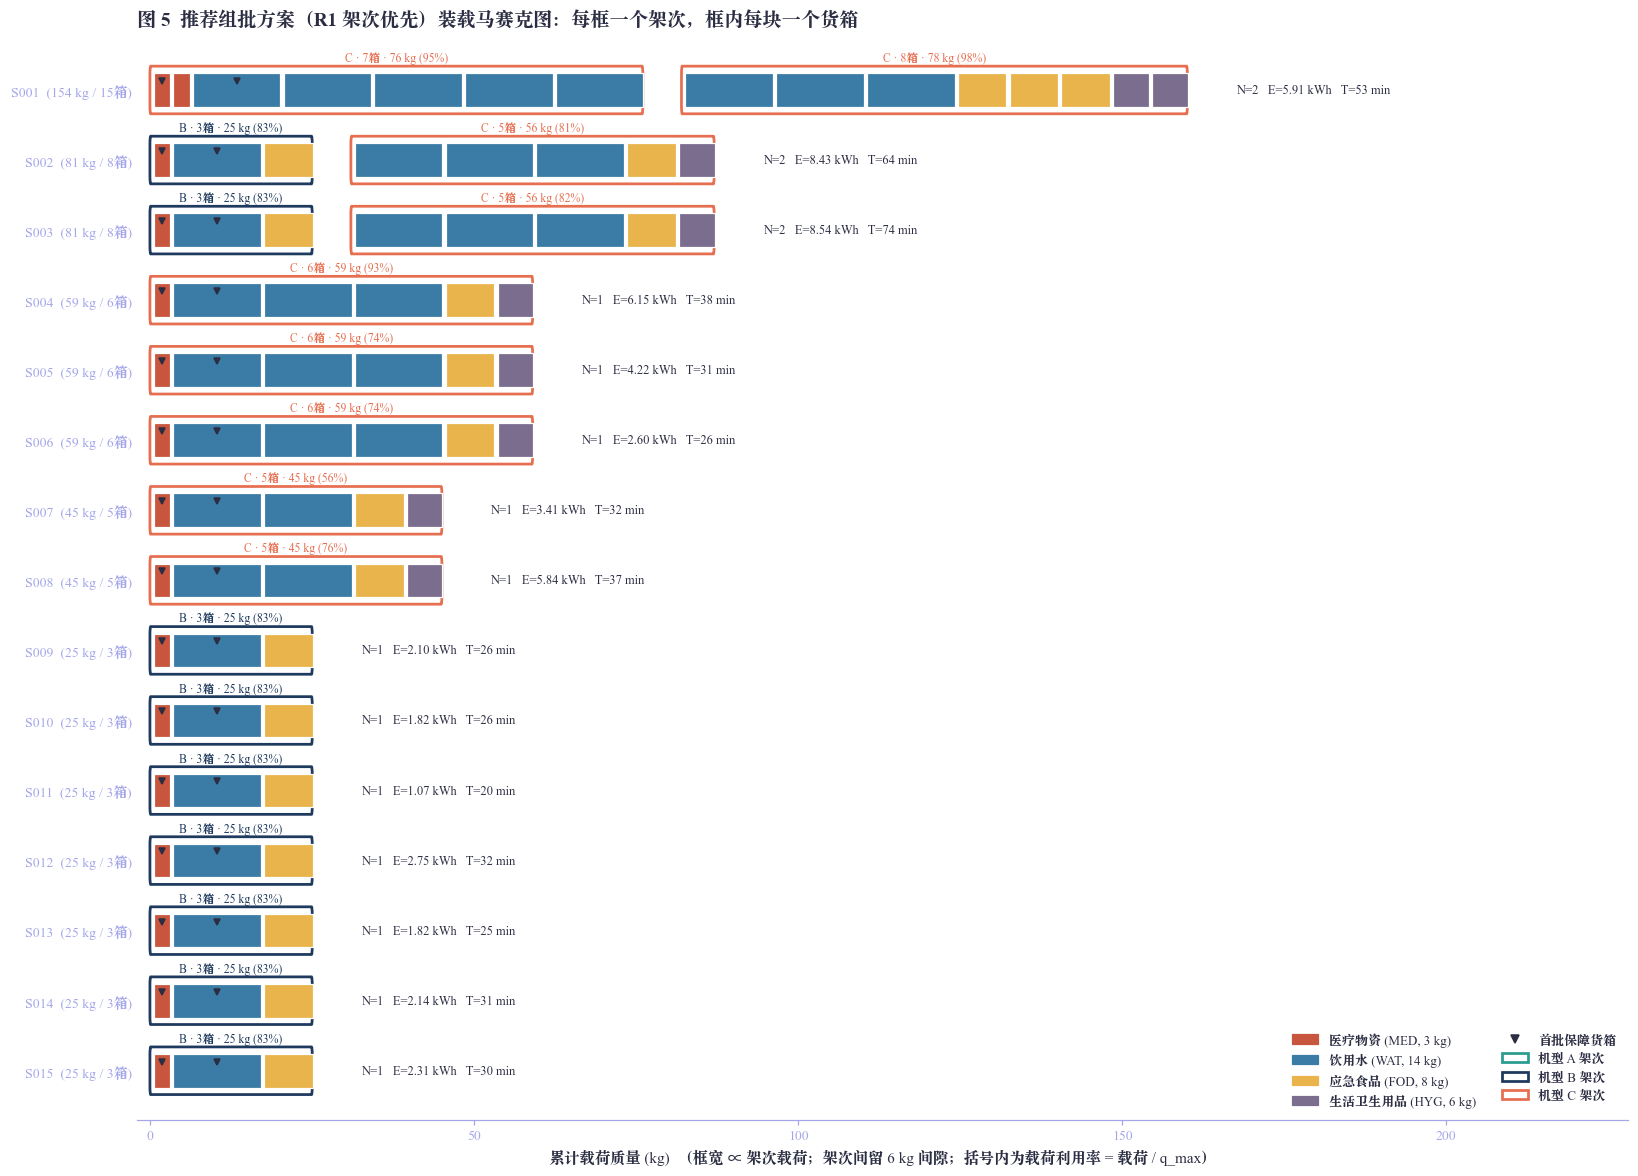

In [12]:
area_sum=boxes.groupby('area').agg(箱数=('box','size'),总质量kg=('mass','sum')).reindex(AREA_IDS)
order=area_sum.sort_values('总质量kg',ascending=False).index.tolist()
fig,ax=plt.subplots(figsize=(15,10.8)); ax.grid(False)
gap_kg=6.0; x_max=0
for yi,a in enumerate(order[::-1]):
    ss=[s for s in PLAN if s['area']==a]; x=0.0
    for s in ss:
        w=s['mass']; col_g=TYPE_COLOR[s['g']]
        ax.add_patch(FancyBboxPatch((x,yi-.32),w,.64,boxstyle='round,pad=0.02,rounding_size=0.12',facecolor='white',edgecolor=col_g,lw=1.8,zorder=2))
        xb=x+.6
        for b in s['boxes']:
            bm=boxes.set_index('box').loc[b]; wb=bm.mass-.5
            ax.add_patch(Rectangle((xb,yi-.24),wb,.48,facecolor=MAT_COLOR[bm.mat],edgecolor='white',lw=.8,zorder=3))
            if bm['first']:
                ax.plot([xb+wb/2],[yi+.13],marker='v',ms=4,color=PAL['ink'],zorder=4)
            xb+=bm.mass
        ax.text(x+w/2,yi+.37,f'{s["g"]} · {s["n"]}箱 · {s["mass"]:.0f} kg ({s["mass_util"]*100:.0f}%)',ha='center',va='bottom',fontsize=7.7,color=col_g)
        x+=w+gap_kg
    x_max=max(x_max,x)
    N=len(ss); E=sum(s['E'] for s in ss); T=sum(s['T'] for s in ss)/60
    ax.text(x+1.5,yi,f'N={N}   E={E:.2f} kWh   T={T:.0f} min',va='center',fontsize=8.2,color=PAL['ink'],family=EN_FONT)
ax.set_yticks(range(len(order))); ax.set_yticklabels([f'{a}  ({area_sum.loc[a,"总质量kg"]:.0f} kg / {int(area_sum.loc[a,"箱数"])}箱)' for a in order[::-1]])
ax.set_xlim(-2,x_max+62); ax.set_ylim(-.7,len(order)-.2)
ax.set_xlabel('累计载荷质量 (kg)  （框宽 ∝ 架次载荷；架次间留 6 kg 间隙；括号内为载荷利用率 = 载荷 / q_max）')
ax.spines['left'].set_visible(False); ax.tick_params(axis='y',length=0)
handles=[Rectangle((0,0),1,1,color=MAT_COLOR[m],label=f'{m} ({MAT_ABBR[m]}, {boxes[boxes.mat==m].mass.iloc[0]:.0f} kg)') for m in MAT_ORDER]
handles += [Line2D([],[],marker='v',color=PAL['ink'],ls='none',ms=5,label='首批保障货箱')]
handles += [Rectangle((0,0),1,1,facecolor='white',edgecolor=TYPE_COLOR[g],lw=1.8,label=f'机型 {g} 架次') for g in TYPES]
ax.legend(handles=handles,loc='lower right',ncol=2,fontsize=8.5,frameon=True,framealpha=.9,edgecolor='none')
ax.set_title('图 5  推荐组批方案（R1 架次优先）装载马赛克图：每框一个架次，框内每块一个货箱',loc='left',fontsize=12.5)
fig.tight_layout(); savefig(fig,'图05_组批方案装载马赛克图'); plt.show()

## 14 图 6：指标权衡——决策规则一致性与机型策略比较

**(a)** 四种决策规则在全局 $N/E/T$ 上的平行坐标（以全局理想点归一化）：折线重合说明在当前安全余量下三指标之间没有实质冲突，唯一的分歧来自 S008——能耗优先规则用 2 架 B 换 1 架 C，能耗只省约 0.1 kWh，却多付出 1 个架次和近 28 min 作业时间。**(b)** 机型策略的三指标条形比较（以推荐策略为 1.0）：单一轻载机型 A 需要近 3 倍架次与作业时间。**(c)(d)** 各服务区在“仅 B / 仅 C / 混合”下的能耗与作业时间哑铃图，哑铃越长说明该服务区对机型选择越敏感——远距离、大需求的 S002、S003 最敏感。

🖼️ 已保存 math_modeling_q1_run/图06_指标权衡与机型策略.png


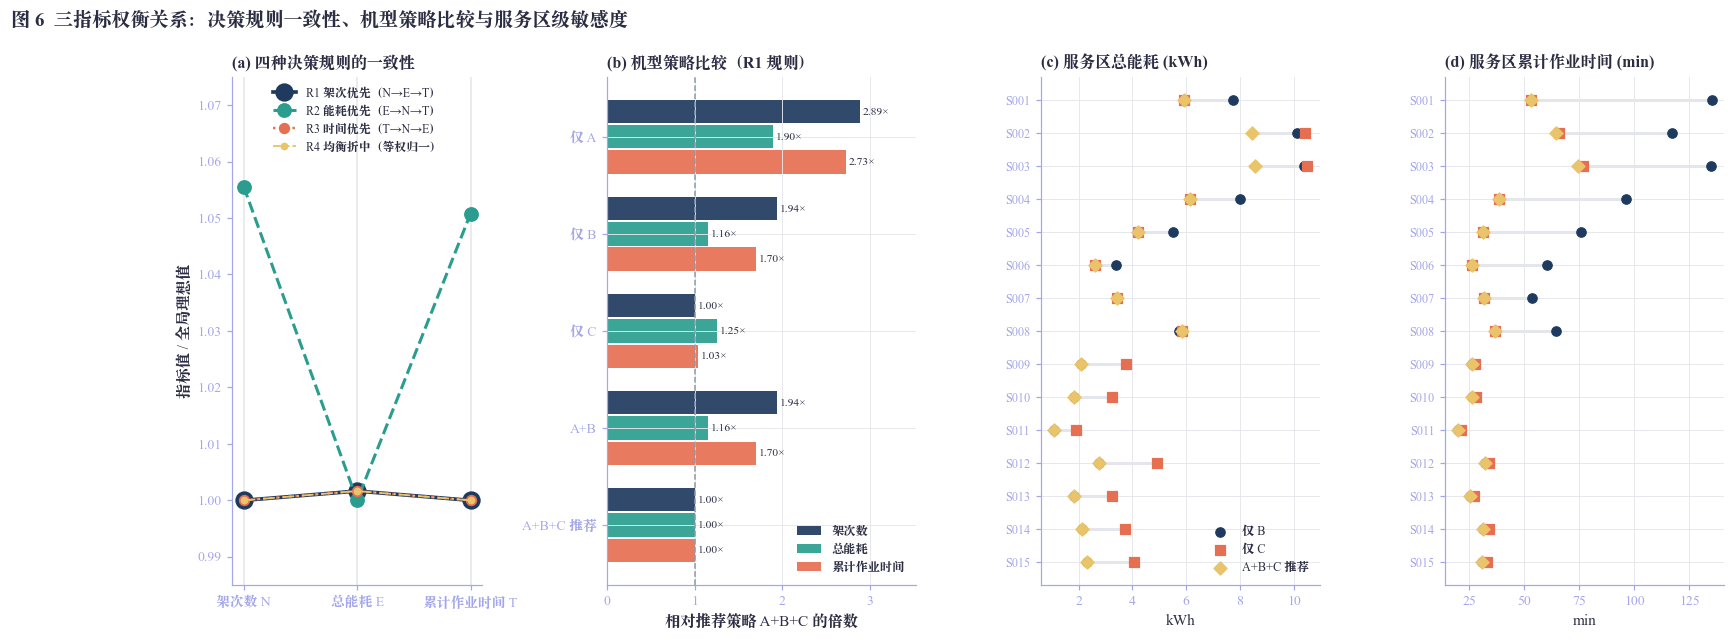

In [13]:
fig=plt.figure(figsize=(17.5,6.0)); gs=fig.add_gridspec(1,4,width_ratios=[.85,1.05,.95,.95],wspace=.45)
rule_cols=[PAL['indigo'],PAL['teal'],PAL['coral'],PAL['gold']]; rule_ls=['-','--',':','-.']
metrics=['架次数','总能耗kWh','累计作业时间h']; ideal_vec=np.array([ideal[0],ideal[1],ideal[2]/3600])
# (a) 平行坐标
ax=fig.add_subplot(gs[0]); ax.grid(False)
for k,(rname,row) in enumerate(rule_df.iterrows()):
    y=row[metrics].to_numpy(dtype=float)/ideal_vec
    ax.plot(range(3),y,marker='o',ms=11-2.3*k,lw=2.4-.4*k,ls=rule_ls[k],color=rule_cols[k],label=rname,zorder=4+k)
for j in range(3): ax.axvline(j,color=PAL['mist'],lw=1,zorder=1)
ax.set_xticks(range(3)); ax.set_xticklabels(['架次数 N','总能耗 E','累计作业时间 T'])
ax.set_ylabel('指标值 / 全局理想值'); ax.set_ylim(.985,1.075); ax.legend(loc='upper center',fontsize=7.8)
ax.set_title('(a) 四种决策规则的一致性',loc='left',fontsize=10.5)
# (b) 机型策略条形
ax=fig.add_subplot(gs[1]); base=policy_df.loc['A+B+C 推荐']; pol_names=policy_df.index.tolist(); ybase=np.arange(len(pol_names))
cols3=[PAL['indigo'],PAL['teal'],PAL['coral']]; labs=['架次数','总能耗','累计作业时间']
for k,m in enumerate(['架次数','总能耗kWh','累计作业时间h']):
    vals=policy_df[m].to_numpy(dtype=float)/base[m]
    ax.barh(ybase+(k-1)*.26,vals,height=.24,color=cols3[k],label=labs[k],alpha=.92)
    for y,v in zip(ybase+(k-1)*.26,vals): ax.text(v+.03,y,f'{v:.2f}×',va='center',fontsize=7.6)
ax.axvline(1,color=PAL['grey'],ls='--',lw=1); ax.set_yticks(ybase); ax.set_yticklabels(pol_names); ax.invert_yaxis()
ax.set_xlim(0,policy_df[['架次数','总能耗kWh','累计作业时间h']].div(base[['架次数','总能耗kWh','累计作业时间h']]).to_numpy().max()*1.22)
ax.set_xlabel('相对推荐策略 A+B+C 的倍数'); ax.legend(loc='lower right',fontsize=8)
ax.set_title('(b) 机型策略比较（R1 规则）',loc='left',fontsize=10.5)
# (c)(d) 服务区级哑铃图
pol3=[('仅 B',TYPE_COLOR['B'],'o'),('仅 C',TYPE_COLOR['C'],'s'),('A+B+C 推荐',PAL['gold'],'D')]
for gi,(key,ttl,unit,col) in enumerate([(1,'(c) 服务区总能耗 (kWh)','kWh',PAL['teal']),(2,'(d) 服务区累计作业时间 (min)','min',PAL['coral'])]):
    ax=fig.add_subplot(gs[2+gi])
    for yi,a in enumerate(AREA_IDS):
        vals=[policy_area[pn][a][key]/(60 if key==2 else 1) for pn,_,_ in pol3]
        ax.plot([min(vals),max(vals)],[yi,yi],color=PAL['mist'],lw=2,zorder=1)
        for pn,co,mk in pol3:
            v=policy_area[pn][a][key]/(60 if key==2 else 1)
            ax.scatter(v,yi,s=38,color=co,marker=mk,zorder=3,label=pn if yi==0 else None)
    ax.set_yticks(range(len(AREA_IDS))); ax.set_yticklabels(AREA_IDS,fontsize=8); ax.invert_yaxis(); ax.set_xlabel(unit)
    ax.set_title(ttl,loc='left',fontsize=10.5)
    if gi==0:ax.legend(loc='lower right',fontsize=8)
fig.suptitle('图 6  三指标权衡关系：决策规则一致性、机型策略比较与服务区级敏感度',x=.01,ha='left',fontsize=12.5,fontweight='bold')
savefig(fig,'图06_指标权衡与机型策略'); plt.show()

## 15 图 7：推荐方案的能耗与时间构成

按服务区把总能耗拆成“去程水平 / 去程爬升 / 回程水平 / 回程爬升”四段堆叠，右轴叠加累计作业时间（菱形）及其中的纯飞行时间（空心）。它揭示两个建模事实：① 水平巡航能耗占绝对主导，爬升项即使在高落差服务区（S003、S014、S015）也只占约 5%–10%，说明**距离才是能耗的第一驱动因素**；② 作业时间中固定准备 + 交接（每架次 450–480 s）与飞行时间同量级，因此“减少架次”同时也是“减少时间”，这就是三指标高度一致的机理。

↳ 已生成 图07_能耗构成与作业时间.png（嵌入 Notebook；运行时将保存至配置目录）


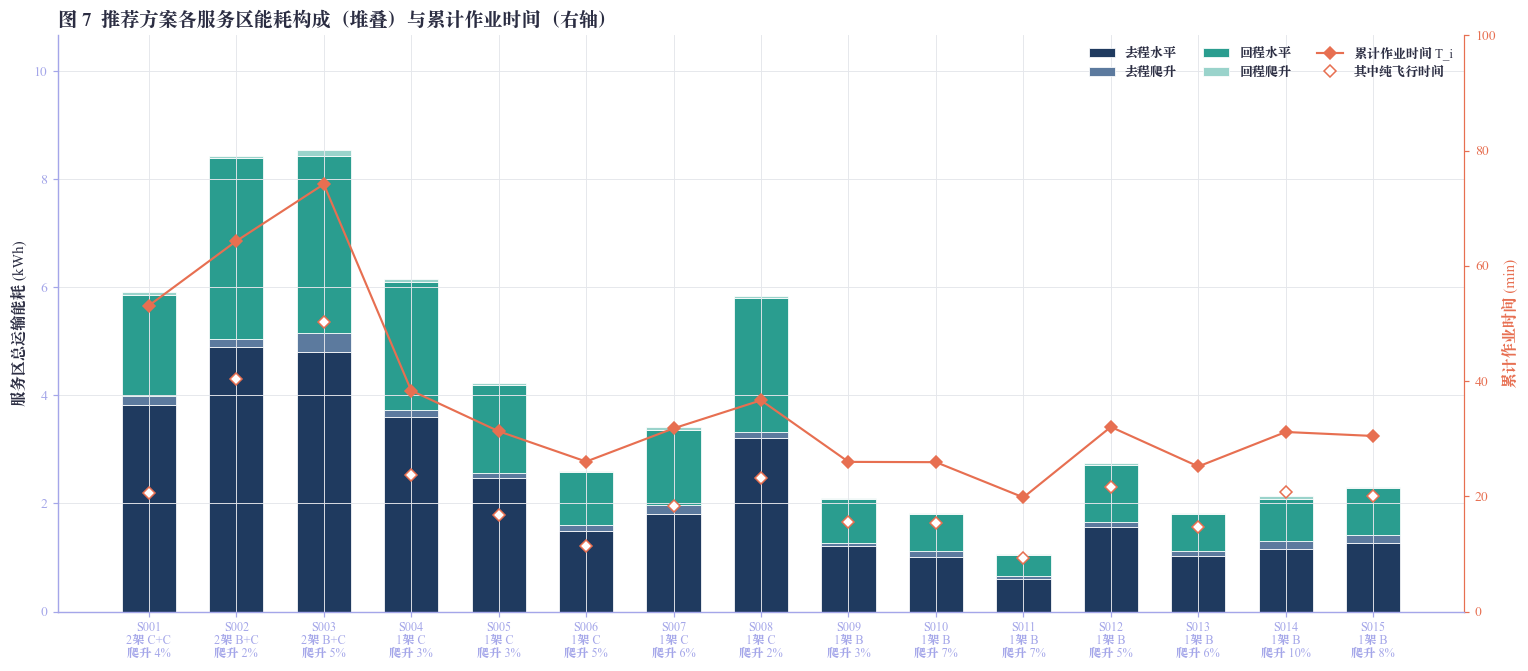

全局能耗构成：去程水平 33.94 kWh (57.4%), 去程爬升 2.00 kWh (3.4%), 回程水平 22.63 kWh (38.3%), 回程爬升 0.55 kWh (0.9%)
全局：18 架次、59.13 kWh、累计作业 9.10 h（其中飞行 5.36 h，地面准备/装载/交接 3.75 h）


In [14]:
agg=[]
for a in AREA_IDS:
    ss=[s for s in PLAN if s['area']==a]
    parts=np.sum([s['E_parts'] for s in ss],axis=0)
    agg.append(dict(area=a,N=len(ss),去程水平=parts[0],去程爬升=parts[1],回程水平=parts[2],回程爬升=parts[3],
                    T=sum(s['T'] for s in ss)/60,T_fly=sum(s['T_fly'] for s in ss)/60,types='+'.join(sorted(s['g'] for s in ss))))
agg=pd.DataFrame(agg).set_index('area')
fig,ax=plt.subplots(figsize=(14,6.2)); x=np.arange(len(agg))
comp_cols=['#1F3A5F','#5C7A9E','#2A9D8F','#9AD3CB']; bottom=np.zeros(len(agg))
for c,col in zip(['去程水平','去程爬升','回程水平','回程爬升'],comp_cols):
    ax.bar(x,agg[c],bottom=bottom,color=col,width=.62,label=c,edgecolor='white',lw=.5); bottom+=agg[c].values
agg['爬升占比%']=(agg.去程爬升+agg.回程爬升)/bottom*100
ax.set_xticks(x); ax.set_xticklabels([f'{a}\n{int(r.N)}架 {r.types}\n爬升 {r["爬升占比%"]:.0f}%' for a,r in agg.iterrows()],fontsize=8,linespacing=1.1)
ax.set_ylabel('服务区总运输能耗 (kWh)'); ax.set_ylim(0,bottom.max()*1.25)
ax2=ax.twinx(); ax2.grid(False); ax2.spines['right'].set_visible(True); ax2.spines['right'].set_color(PAL['coral'])
ax2.plot(x,agg['T'],marker='D',ms=6,color=PAL['coral'],lw=1.4,label='累计作业时间 T_i')
ax2.plot(x,agg['T_fly'],marker='D',ms=6,markerfacecolor='white',color=PAL['coral'],lw=0,label='其中纯飞行时间')
ax2.set_ylabel('累计作业时间 (min)',color=PAL['coral']); ax2.tick_params(axis='y',colors=PAL['coral']); ax2.set_ylim(0,agg['T'].max()*1.35)
h1,l1=ax.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
ax.legend(h1+h2,l1+l2,loc='upper right',ncol=3,fontsize=8.5)
ax.set_title('图 7  推荐方案各服务区能耗构成（堆叠）与累计作业时间（右轴）',loc='left',fontsize=12.5)
fig.tight_layout(); savefig(fig,'图07_能耗构成与作业时间'); plt.show()
tot=agg[['去程水平','去程爬升','回程水平','回程爬升']].sum()
print('全局能耗构成：'+', '.join(f'{k} {v:.2f} kWh ({v/tot.sum()*100:.1f}%)' for k,v in tot.items()))
print(f'全局：{int(agg.N.sum())} 架次、{tot.sum():.2f} kWh、累计作业 {agg["T"].sum()/60:.2f} h（其中飞行 {agg["T_fly"].sum()/60:.2f} h，'
      f'地面准备/装载/交接 {(agg["T"].sum()-agg["T_fly"].sum())/60:.2f} h）')

## 16 返航安全余量 $\rho$ 的敏感性分析

**扰动设计。** 三种机型统一取 $\rho\in[0.05,0.45]$，步长 0.01（共 41 个水平，附件基准 $\rho=0.20$），每个水平重新计算全部 $q_{gi}^{\max}$ 并重新求解组批。之所以扫到 0.45，是为了看到两类临界现象：

1. **能量约束接管点** $\rho_{gi}^{cap}$：$q^{\max}$ 开始低于结构上限 $Q_g$ 的最小 $\rho$；
2. **不可行点** $\rho_{gi}^{inf}$：空载往返都无法满足余量、该机型对该服务区失效的 $\rho$。

二者之间就是该（机型，服务区）组合的**安全余量工作窗口**。

**关注的响应。** ① $q^{\max}$–$\rho$ 曲线族（每机型 15 条）；② 全局 $N/E/T$ 与机型构成随 $\rho$ 的阶梯变化；③ 各服务区架次数随 $\rho$ 的变化热图（阶跃点即组批方案发生结构性变化的位置）；④ 何时出现三指标冲突（Pareto 前沿点数 $>1$）。

In [15]:
RHO_GRID=np.round(np.arange(.05,.451,.01),2)
sens_q={}; sens_rows=[]; sens_area_N=pd.DataFrame(index=AREA_IDS,columns=RHO_GRID,dtype=float)
for rho in RHO_GRID:
    qm,bd=compute_qmax({name:rho for name in TYPES}); sens_q[rho]=(qm,bd)
    sols=solve_all(qm)
    chosen={a:pick(s.front,'NET') for a,s in sols.items()}
    missing=[a for a,c in chosen.items() if c is None]
    conflict=[a for a,s in sols.items() if len(s.front)>1]
    count={name:0 for name in TYPES}
    for a,s in sols.items():
        c=chosen[a]
        if c is None: continue
        plan=s.reconstruct(c,qm); sens_area_N.loc[a,rho]=len(plan)
        for trip in plan: count[trip['g']]+=1
    complete=not missing
    sens_rows.append(dict(rho=rho,N=sum(c[0] for c in chosen.values() if c),
                          E=sum(c[1] for c in chosen.values() if c),
                          T_h=sum(c[2] for c in chosen.values() if c)/3600,
                          A=count['A'],B=count['B'],C=count['C'],complete=complete,
                          missing=','.join(missing),conflict_count=len(conflict),
                          conflict_areas=','.join(conflict) if conflict else '—',
                          front_points=len(global_front([s.front for s in sols.values()])) if complete else 0))
sens_df=pd.DataFrame(sens_rows).set_index('rho')
print(f'敏感性扫描完成：{len(RHO_GRID)} 个 ρ 水平；ρ ≤ {sens_df.index[sens_df.complete].max():.2f} 时可覆盖全部服务区')
display(sens_df.loc[[.05,.10,.15,.20,.25,.30,.35,.40,.45]].rename(columns={
    'T_h':'T','complete':'全覆盖','missing':'不可覆盖',
    'conflict_count':'冲突服务区数','conflict_areas':'冲突服务区',
    'front_points':'全局Pareto点数'}).round(3))
print('扫描网格内完整覆盖的最大余量：',sens_df.index[sens_df.complete].max())
win=[]
for name in TYPES:
    p=uav.loc[name]
    for a in AREA_IDS:
        e0=sortie_energy(p,SEG[a],0); eq=sortie_energy(p,SEG[a],p.Q)
        win.append(dict(model=name,area=a,rho_cap=max(0.0,1-eq/p.E_use),rho_inf=1-e0/p.E_use))
win_df=pd.DataFrame(win)
RHO_FEAS_MAX=float(sens_df.index[sens_df.complete].max())
display(win_df.pivot(index='area',columns='model',values=['rho_cap','rho_inf']).round(3))

first_inf=sens_df.index[~sens_df.complete].min()
qa=sens_q[first_inf][0].loc[sens_df.loc[first_inf,'missing'].split(',')[0]]
print(f'首个不可覆盖出现在 ρ = {first_inf:.2f}（{sens_df.loc[first_inf,"missing"]}）：此时三机型 q_max = '+', '.join(f'{g}:{qa[g]:.1f}' for g in TYPES)+
      f' kg，均低于最重单箱 {boxes.mass.max():.0f} kg（饮用水）。因此并非“空载不可行”，而是“载不动任何一箱水”。')


敏感性扫描完成：41 个 ρ 水平；ρ ≤ 0.35 时可覆盖全部服务区


,N,E,T,A,B,C,全覆盖,不可覆盖,冲突服务区数,冲突服务区,全局Pareto点数
rho,,,,,,,,,,,
0.05,18,59.131,9.104,0,9,9,True,,1,S008,2
0.10,18,59.131,9.104,0,9,9,True,,1,S008,2
0.15,18,59.131,9.104,0,9,9,True,,1,S008,2
0.20,18,59.131,9.104,0,9,9,True,,1,S008,2
0.25,19,61.073,9.602,0,10,9,True,,2,"S004,S008",6
0.30,20,67.228,10.163,0,9,11,True,,4,"S002,S003,S004,S008",13
0.35,25,75.608,12.607,0,15,10,True,,4,"S002,S003,S004,S012",24
0.40,25,72.396,12.398,0,15,10,False,"S004,S008",1,S003,0
0.45,11,29.178,5.050,0,5,6,False,"S002,S003,S004,S008,S012",1,S015,0


扫描网格内完整覆盖的最大余量： 0.35


rho_cap               rho_inf              
model       A      B      C       A      B      C
area                                             
S001    0.708  0.682  0.615   0.742  0.767  0.757
S002    0.313  0.250  0.082   0.391  0.454  0.421
S003    0.298  0.234  0.077   0.380  0.441  0.420
S004    0.274  0.208  0.036   0.357  0.422  0.392
S005    0.501  0.455  0.338   0.558  0.603  0.583
S006    0.691  0.662  0.593   0.728  0.755  0.745
S007    0.552  0.510  0.415   0.605  0.642  0.633
S008    0.247  0.178  0.000   0.333  0.402  0.367
S009    0.470  0.421  0.291   0.530  0.578  0.554
S010    0.540  0.497  0.393   0.594  0.634  0.619
S011    0.729  0.704  0.643   0.761  0.784  0.776
S012    0.304  0.240  0.075   0.384  0.446  0.418
S013    0.539  0.496  0.389   0.593  0.634  0.616
S014    0.461  0.411  0.299   0.525  0.570  0.560
S015    0.418  0.364  0.233   0.487  0.537  0.520

首个不可覆盖出现在 ρ = 0.36（S008）：此时三机型 q_max = A:nan, B:12.7, C:8.6 kg，均低于最重单箱 14 kg（饮用水）。因此并非“空载不可行”，而是“载不动任何一箱水”。


## 17 图 8、图 9：敏感性响应

**图 8：** (a)–(c) 三种机型的 $q^{\max}$–$\rho$ 曲线族（灰线为 15 个服务区，加粗线为最不利与最有利服务区，虚线为结构上限）；(d)–(f) 全局架次数（叠加机型构成）、总能耗、累计作业时间随 $\rho$ 的阶梯响应，只在“仍可覆盖全部服务区”的 $\rho$ 区间内绘制，右侧红色区域为出现不可覆盖服务区的范围。**图 9：** (a) 各（机型，服务区）的安全余量工作窗口——条形左端为能量接管点、右端为不可行点，基准 $\rho=0.20$ 用竖线标出，一眼看出哪些组合“余量一收紧就失效”；(b) 各服务区推荐架次数随 $\rho$ 的变化热图，颜色跳变处即组批结构发生变化的临界点，× 表示不可覆盖。

↳ 已生成 图08_敏感性_载荷与三指标.png（嵌入 Notebook；运行时将保存至配置目录）


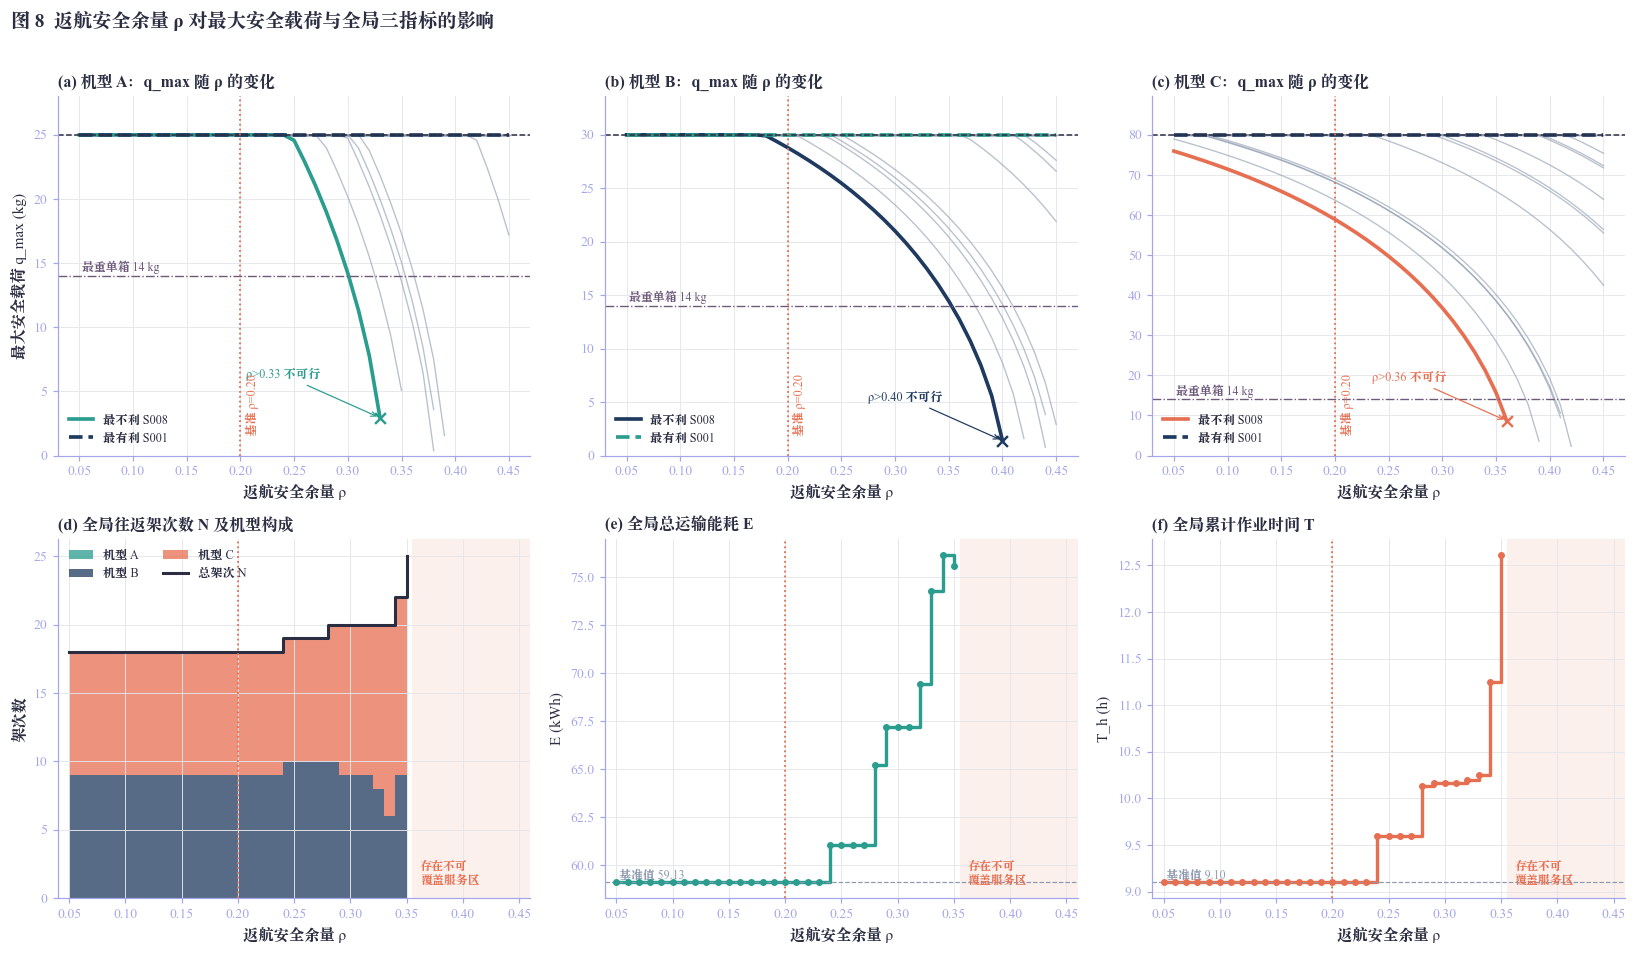

In [16]:
fig,axes=plt.subplots(2,3,figsize=(15,8.8))
rho_idx={r:k for k,r in enumerate(RHO_GRID)}
# 上排：q_max 曲线族
for ax,gname in zip(axes[0],TYPES):
    p=uav.loc[gname]; col=TYPE_COLOR[gname]
    curves=np.array([[sens_q[r][0].loc[a,gname] for r in RHO_GRID] for a in AREA_IDS])
    for k,a in enumerate(AREA_IDS): ax.plot(RHO_GRID,curves[k],color=PAL['grey'],lw=.9,alpha=.6)
    ref=curves[:,rho_idx[.30]]
    k_worst=int(np.nanargmin(np.where(np.isnan(ref),np.inf,ref)))
    k_best=int(np.nanargmax(np.where(np.isnan(ref),-np.inf,ref)))
    ax.plot(RHO_GRID,curves[k_worst],color=col,lw=2.4,label=f'最不利 {AREA_IDS[k_worst]}')
    ax.plot(RHO_GRID,curves[k_best],color=PAL['indigo'] if gname!='B' else PAL['teal'],lw=2.4,ls='--',label=f'最有利 {AREA_IDS[k_best]}')
    last=np.where(np.isnan(curves[k_worst]))[0]
    if len(last) and last[0]>0:
        r_end=RHO_GRID[last[0]-1]
        ax.scatter([r_end],[curves[k_worst,last[0]-1]],marker='x',s=50,color=col,zorder=5)
        ax.annotate(f'ρ>{r_end:.2f} 不可行',(r_end,curves[k_worst,last[0]-1]),xytext=(-88,26),textcoords='offset points',fontsize=8,color=col,arrowprops=dict(arrowstyle='->',color=col))
    ax.axhline(p.Q,color=PAL['ink'],ls='--',lw=1)
    ax.axhline(boxes.mass.max(),color=PAL['plum'],ls='-.',lw=.9)
    ax.text(.052,boxes.mass.max()+p.Q*.015,f'最重单箱 {boxes.mass.max():.0f} kg',fontsize=7.8,color=PAL['plum'])
    ax.axvline(.20,color=PAL['coral'],ls=':',lw=1.2)
    ax.text(.205,p.Q*.06,'基准 ρ=0.20',color=PAL['coral'],fontsize=8,rotation=90,va='bottom')
    ax.set_title(f'({"abc"[TYPES.index(gname)]}) 机型 {gname}：q_max 随 ρ 的变化',loc='left',fontsize=10.5)
    ax.set_xlabel('返航安全余量 ρ'); ax.set_ylim(0,p.Q*1.12); ax.legend(loc='lower left',fontsize=8)
axes[0,0].set_ylabel('最大安全载荷 q_max (kg)')
# 下排：全局 N / E / T 阶梯（仅全覆盖区间）
feas=sens_df[sens_df.complete]; rf=feas.index.to_numpy(dtype=float)
ax=axes[1,0]
ax.stackplot(rf,feas['A'],feas['B'],feas['C'],step='post',colors=[TYPE_COLOR[g] for g in TYPES],alpha=.75,labels=[f'机型 {g}' for g in TYPES])
ax.step(rf,feas['N'],where='post',color=PAL['ink'],lw=2,label='总架次 N')
ax.set_title('(d) 全局往返架次数 N 及机型构成',loc='left',fontsize=10.5); ax.set_ylabel('架次数'); ax.legend(loc='upper left',fontsize=8,ncol=2)
for ax,(m,ttl,unit,col) in zip(axes[1,1:],[('E','(e) 全局总运输能耗 E','kWh',PAL['teal']),('T_h','(f) 全局累计作业时间 T','h',PAL['coral'])]):
    ax.step(rf,feas[m],where='post',color=col,lw=2.2)
    ax.scatter(rf,feas[m],s=14,color=col,zorder=5)
    ax.set_title(ttl,loc='left',fontsize=10.5); ax.set_ylabel(f'{m} ({unit})')
    base=sens_df.loc[.20,m]
    ax.axhline(base,color=PAL['grey'],lw=.8,ls='--')
    ax.text(.052,base,f'基准值 {base:.2f}',fontsize=7.8,color=PAL['grey'],va='bottom')
for ax in axes[1]:
    ax.axvline(.20,color=PAL['coral'],ls=':',lw=1.2)
    ax.axvspan(RHO_FEAS_MAX+.005,.46,color=PAL['coral'],alpha=.10,lw=0)
    ax.text(RHO_FEAS_MAX+.012,ax.get_ylim()[0]+.04*np.diff(ax.get_ylim())[0],'存在不可\n覆盖服务区',fontsize=7.8,color=PAL['coral'])
    ax.set_xlabel('返航安全余量 ρ'); ax.set_xlim(.04,.46)
fig.suptitle('图 8  返航安全余量 ρ 对最大安全载荷与全局三指标的影响',x=.01,ha='left',fontsize=12.5,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.97]); savefig(fig,'图08_敏感性_载荷与三指标'); plt.show()

↳ 已生成 图09_安全余量工作窗口与架次热图.png（嵌入 Notebook；运行时将保存至配置目录）


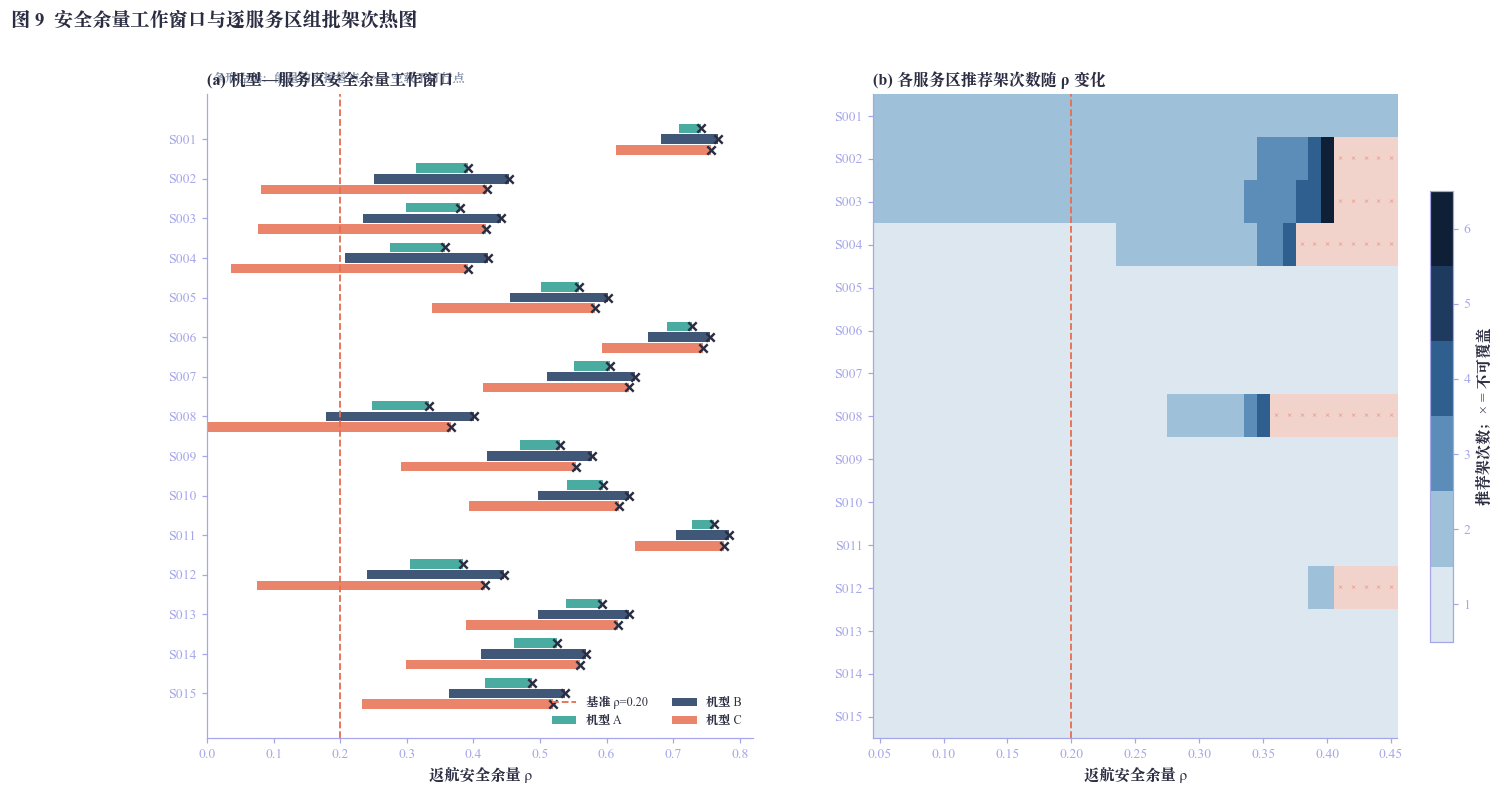

In [17]:
fig=plt.figure(figsize=(15.5,7.6)); gs=fig.add_gridspec(1,2,width_ratios=[1.0,1.2],wspace=.2)
# (a) 工作窗口
ax=fig.add_subplot(gs[0]); ax.grid(False)
win_p=win_df.copy(); win_p['y']=[AREA_IDS.index(a)+{'A':-.27,'B':0.0,'C':.27}[g] for a,g in zip(win_p.area,win_p.model)]
for gname in TYPES:
    d=win_p[win_p.model==gname]; col=TYPE_COLOR[gname]
    ax.barh(d.y,d.rho_inf-d.rho_cap,left=d.rho_cap,height=.24,color=col,alpha=.85,label=f'机型 {gname}')
    ax.scatter(d.rho_inf,d.y,marker='x',s=30,color=PAL['ink'],zorder=5)
ax.axvline(.20,color=PAL['coral'],ls='--',lw=1.2,label='基准 ρ=0.20')
ax.set_yticks(range(len(AREA_IDS))); ax.set_yticklabels(AREA_IDS); ax.invert_yaxis()
ax.set_xlabel('返航安全余量 ρ'); ax.set_xlim(0,.82)
ax.set_title('(a) 机型—服务区安全余量工作窗口',loc='left',fontsize=10.5)
ax.legend(loc='lower right',fontsize=8,ncol=2)
ax.text(.01,1.02,'条形左端：能量约束接管点    ×：空载不可行点',transform=ax.transAxes,fontsize=8,color=PAL['grey'])
# (b) 架次数热图
ax=fig.add_subplot(gs[1]); ax.grid(False)
M=sens_area_N.to_numpy(dtype=float)
cmap_N=ListedColormap(['#DDE7F0','#9FC0D9','#5C8DB8','#2F5F8F','#1F3A5F','#0F1F35']); cmap_N.set_bad('#F2D3CC')
im=ax.imshow(M,aspect='auto',cmap=cmap_N,vmin=.5,vmax=6.5,interpolation='nearest')
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if np.isnan(M[i,j]): ax.text(j,i,'×',ha='center',va='center',fontsize=6,color=PAL['coral'])
ax.set_yticks(range(len(AREA_IDS))); ax.set_yticklabels(AREA_IDS)
ax.set_xticks(range(0,len(RHO_GRID),5)); ax.set_xticklabels([f'{RHO_GRID[j]:.2f}' for j in range(0,len(RHO_GRID),5)])
ax.axvline(rho_idx[.20],color=PAL['coral'],ls='--',lw=1.2)
ax.set_xlabel('返航安全余量 ρ'); ax.set_title('(b) 各服务区推荐架次数随 ρ 变化',loc='left',fontsize=10.5)
fig.colorbar(im,ax=ax,label='推荐架次数；× = 不可覆盖',shrink=.7)
fig.suptitle('图 9  安全余量工作窗口与逐服务区组批架次热图',x=.01,ha='left',fontsize=12.5,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.97]); savefig(fig,'图09_安全余量工作窗口与架次热图'); plt.show()